# Simulations Results
From: Entanglement generation and characterization using metamaterial resonators

Alessandro S. Santana

In [495]:
%matplotlib inline
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from numpy import *
from qutip import *
from IPython.display import Image
from numpy.linalg import *
import multiprocessing  
from multiprocessing import Pool, cpu_count
import scipy.constants as sc
import time
import datetime
import os
import glob
from matplotlib import cm
from matplotlib import gridspec
import matplotlib as mpl

ls = 30.0   # tick label size
fs = 30.0   # axis label size

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    # ===== Fonts =====
    "font.size": 30,
    "axes.labelsize": fs,
    "axes.titlesize": 30,
    # ===== Lines =====
    "lines.linewidth": 2.5,
    # ===== Ticks =====
    "xtick.labelsize": ls,
    "ytick.labelsize": ls,
    "xtick.direction": "in",  
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    # Tick size 
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    # ===== Axes =====
    "axes.linewidth": 2.5,
    "axes.grid": False, 
    # ===== Legend =====
    "legend.frameon": False,
    "legend.fontsize": 15,
    # ===== Figure =====
    "figure.figsize": (16, 6),
    "figure.dpi": 100
})

##############################################################
wr = 2 * pi * 1e6 * 20  # Mechanical Frequency
##############################################################

saveResults = True

In [496]:
def load_result(folder):
    files = glob.glob(os.path.join(folder, "Results_*.npy"))
    
    if not files:
        raise FileNotFoundError("No result files found.")
    
    # Sort by modification time (newest first)
    files_sorted = sorted(files, key=os.path.getmtime, reverse=True)
    
    print("\nAvailable files:")
    for i, f in enumerate(files_sorted):
        print(f"[{i}] {os.path.basename(f)}")
    
    choice = input("\nLoad most recent file? (y/n): ").strip().lower()

    if choice in ['', 'y']:
        selected_file = files_sorted[0]
    else:
        idx = int(input("Enter file index: "))
        if idx < 0 or idx >= len(files_sorted):
            raise ValueError("Invalid index.")
        selected_file = files_sorted[idx]
    
    print(f"\nLoading: {selected_file}\n")
    
    return load(selected_file, allow_pickle=True)

def save_figure(fig, folder, name, formats=("pdf", "png"), time_stamp=True, dpi=300):
    
    choice = input("\nSave figure? (y/N): ").strip().lower()
    if choice not in ['y', 'yes']:
        print("Figure not saved.")
        return
    
    os.makedirs(folder, exist_ok=True)
    
    if time_stamp:
        time_str = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
    else:
        time_str = ""
    
    base_path = os.path.join(folder, name + time_str)
    
    saved_files = []
    
    for fmt in formats:
        fmt = fmt.lower()
        
        if fmt == "png":
            fig.savefig(base_path + ".png", dpi=dpi, bbox_inches='tight')
        else:
            fig.savefig(base_path + f".{fmt}", bbox_inches='tight')
        
        saved_files.append(base_path + f".{fmt}")
    
    print("\nSaved:")
    for f in saved_files:
        print(f)

## Simulation 1

In [552]:
folder_1 = "Results/Simulation_1/"
x_list_1, y_list_1, z_list_1 = load_result(folder_1)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

# absA_list,                          #0
# absA_list_2,                        #1
# absB_list,                          #2
# listAux_NumberOp_modeA,             #3
# listAux_NumberOp_modeB,             #4
# listAux_C1,                         #5
# listAux_C2,                         #6
# listAux_Csym,                       #7
# listAux_negativity_modesAB]         #8

##############################################################
wr = 2 * pi * 1e6 * 50  # Mechanical Frequency
##############################################################
shift_n0 = [-(2 * pi * 1e6 * k**2)/(wr) for k in y_list_1]
shift_n1 = [(-(2 * pi * 1e6 * k**2)/(wr))-((2 * pi * 1e6 * 2*k*5)/(wr)) for k in y_list_1]
##############################################################
x0 = x_list_1[0].round()
xf = x_list_1[-1].round()
delta_x = xf - x0

y0 = y_list_1[0].round()
yf = y_list_1[-1].round()
delta_y = yf - y0
##############################################################


Available files:
[0] Results_[2026-04-01]_[12h15m].npy
[1] Results_[2026-04-01]_[11h55m].npy
[2] Results_[2026-04-01]_[11h33m].npy
[3] Results_[2026-04-01]_[11h23m].npy
[4] Results_[2026-04-01]_[11h10m].npy
[5] Results_[2026-03-25]_[15h53m].npy
[6] Results_[2026-03-25]_[14h58m].npy
[7] Results_[2026-03-25]_[14h12m].npy
[8] Results_[2026-03-25]_[13h40m].npy
[9] Results_[2026-03-24]_[01h13m].npy
[10] Results_[2026-03-23]_[17h15m].npy
[11] Results_[2023-08-25]_[10h49m].npy

Loading: Results/Simulation_1\Results_[2026-04-01]_[12h15m].npy



### 1) Average field amplitude $\langle\hat{a}_1\rangle_{ss}$ for cavity 1  - Comparison between QuTiP vs. Eq.(20)

Figure not saved.


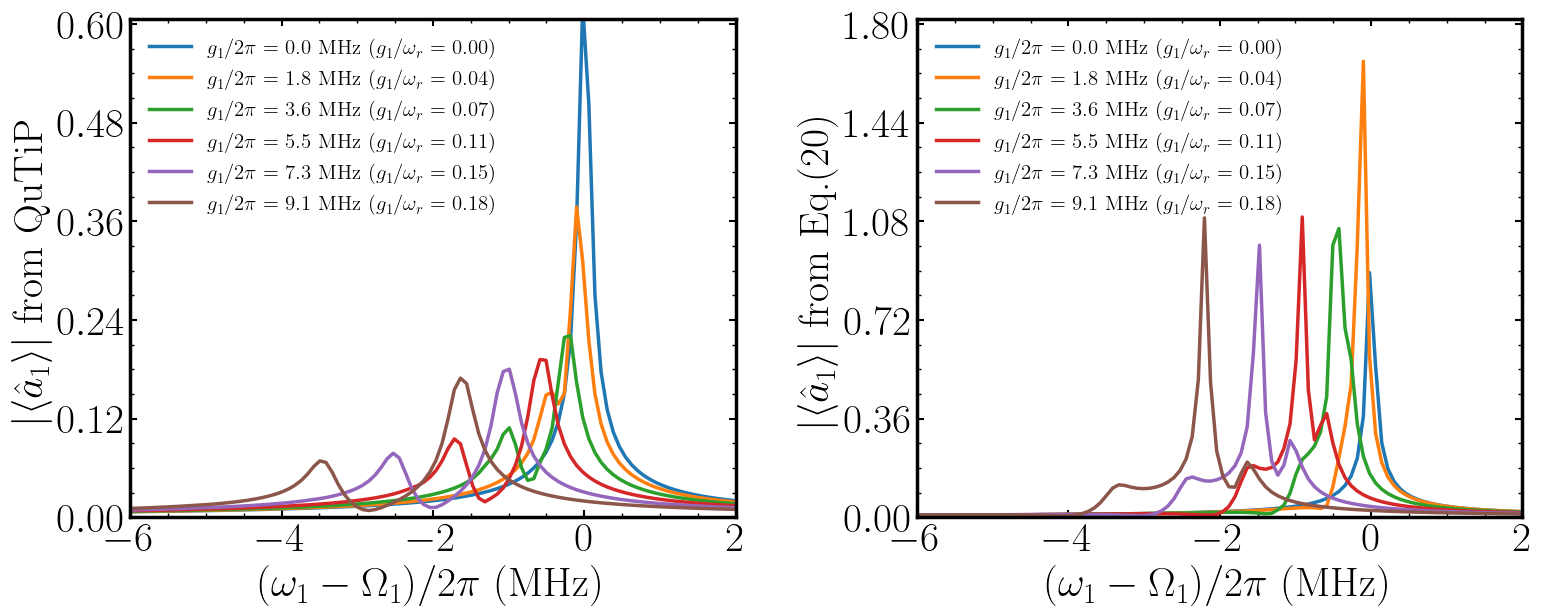

In [570]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
for i in [0,15,30,45,60,75]:
    axes[0].plot(x_list_1, z_list_1[0][i], 
                            linestyle='-', 
                            label=r'$g_1/2\pi = $ %.1f MHz ($g_1/\omega_r = $ %.2f)' % (y_list_1[i],(2 * pi * 1e6 * y_list_1[i]/(wr))))
##############################################################
axes[0].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$\vert\langle \hat{a}_1\rangle\vert$ from QuTiP')

axes[0].legend(loc=2)

start = round(z_list_1[0].min(), 1)
end   = round(z_list_1[0].max(), 1)

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(0.98*start, 1.01*end)
axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(0.98*start, 1.01*end, (end-start)/5))

##############################################################
for i in [0,15,30,45,60,75]:
    axes[1].plot(x_list_1, z_list_1[1][i], 
                 linestyle='-', 
                 label=r'$g_1/2\pi = $ %.1f MHz ($g_1/\omega_r = $ %.2f)' % (y_list_1[i],(2 * pi * 1e6 * y_list_1[i]/(wr))))
##############################################################
axes[1].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[1].set_ylabel(r'$\vert\langle \hat{a}_1\rangle\vert$ from Eq.(20)')

axes[1].legend(loc=2)

start = round(z_list_1[1].min(), 1)
end   = round(z_list_1[1].max(), 1)

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(0.98*start, 1.01*end)
axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(0.98*start, 1.01*end, (end-start)/5))

##############################################################
#axes[0].text(-7.5, 1, r"$\mathbf{a}$", color='black', fontsize=50)
#axes[1].text(-7.5, 1, r"$\mathbf{b}$", color='black', fontsize=50)
##############################################################
# ---- Global spacing ----
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.3   # spacing between the TWO plots only
)
save_figure(fig, folder_1 + "Figures", "Sim1_Fig01", formats=["pdf"])

plt.show()


### 2) Colormap for cavity 1 average field amplitude $\Delta\omega_1 \times g_1 \times \langle\hat{a}_1\rangle_{ss}$

Figure not saved.


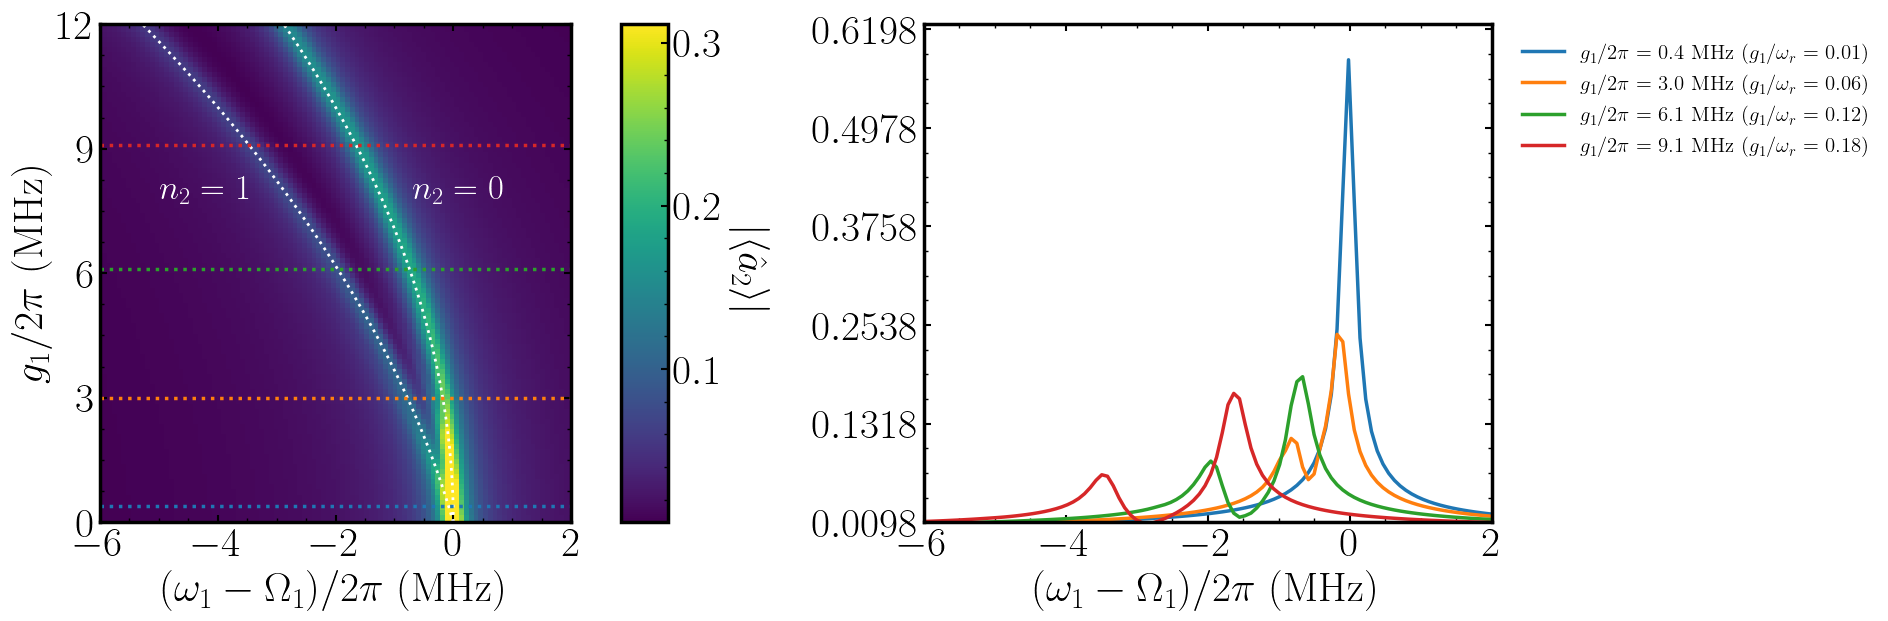

In [569]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
##############################################################
# ---- Heatmap ----
nrm = mpl.colors.Normalize(z_list_1[0].min(), 0.5*z_list_1[0].max())

im1 = axes[0].pcolormesh(
    x_list_1, y_list_1, z_list_1[0],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
axes[0].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)
axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

##############################################################
#  ---- Colorbar settings ----
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",    # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(
    r'$\vert\langle \hat{a}_2\rangle\vert$',
    rotation=270,
    labelpad=35
)

##############################################################
# ---- Overlays ----
axes[0].text(-5, 7.8, r"$n_2 = 1$", color='white', fontsize=25)
axes[0].text(-0.7, 7.8, r"$n_2 = 0$", color='white', fontsize=25)

axes[0].plot(shift_n0, y_list_1, ':', color='white', lw=2)
axes[0].plot(shift_n1, y_list_1, ':', color='white', lw=2)

axes[0].axhline(y=0.4, color='C0', linestyle=':')
axes[0].axhline(y=3.0, color='C1', linestyle=':')
axes[0].axhline(y=6.1, color='C2', linestyle=':')
axes[0].axhline(y=9.1, color='C3', linestyle=':')

##############################################################
# ---- Second plot  ----
for i in [3, 25, 50, 75]:
    axes[1].plot(
        x_list_1,
        z_list_1[0][i],
        label=r'$g_1/2\pi = $ %.1f MHz ($g_1/\omega_r = $ %.2f)' %
        (y_list_1[i], (2 * pi * 1e6 * y_list_1[i] / wr))
    )

axes[1].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

start = round(z_list_1[0].min(), 2)
end   = round(z_list_1[0].max(), 2)

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(0.98*start, 1.01*end)
axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(0.98*start, 1.01*end, (end-start)/5))

##############################################################
# ---- Global spacing ----
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, folder_1 + "Figures", "Sim1_Fig03", formats=["pdf"])

plt.show()

### 3) Colormap for cavity 2 average field amplitude $\Delta\omega_1 \times g_1 \times \langle\hat{a}_2\rangle_{ss}$

Figure not saved.


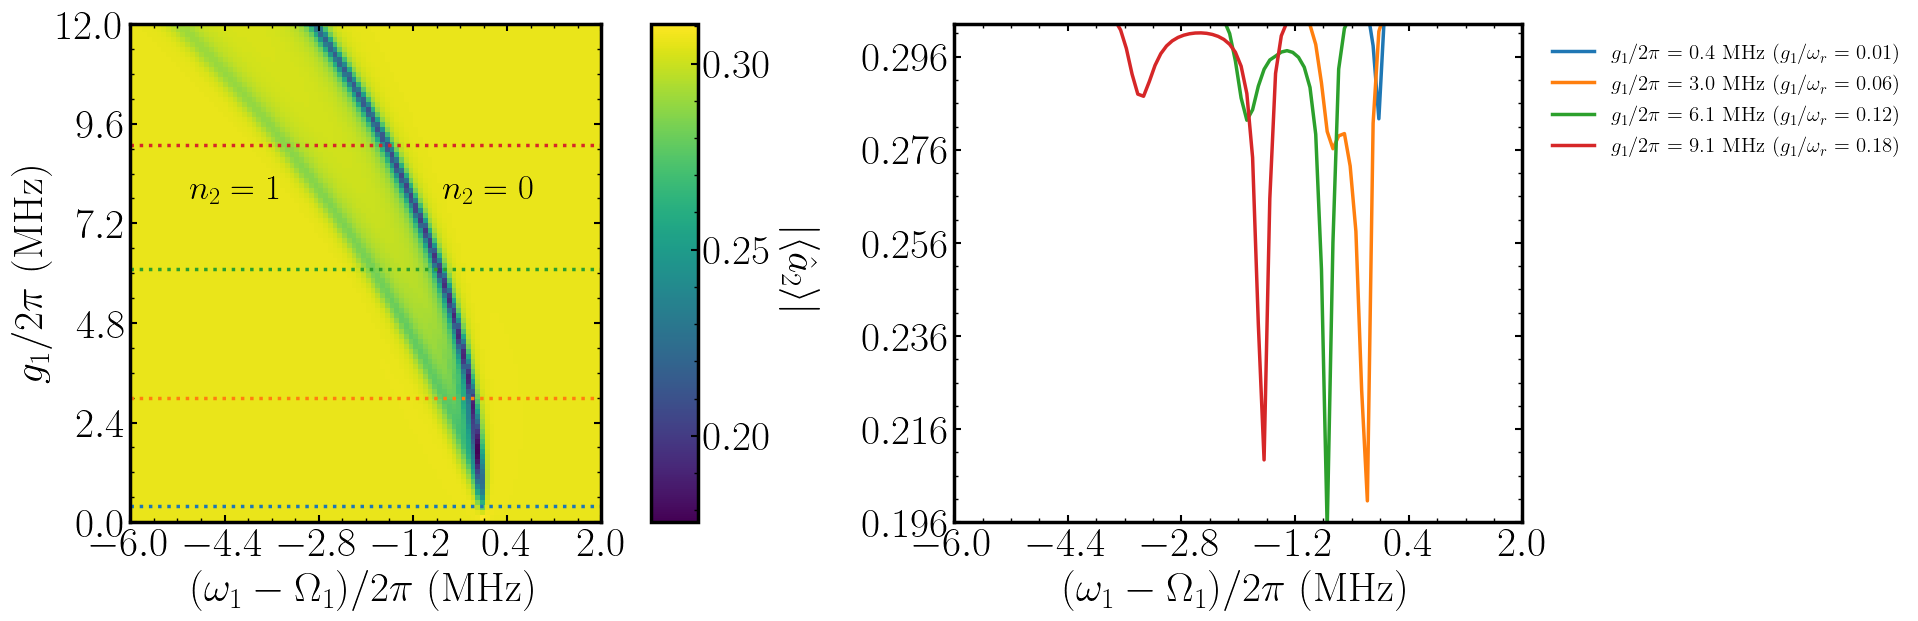

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

##############################################################
# ---- Heatmap ----
nrm = mpl.colors.Normalize(z_list_1[2].min(), z_list_1[2].max())

im1 = axes[0].pcolormesh(
    x_list_1, y_list_1, z_list_1[2],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)

axes[0].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$g_1/2\pi$ (MHz)')

axes[0].set_xlim(x0, xf)
axes[0].set_ylim(y0, yf)
axes[0].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[0].yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

##############################################################
divider = make_axes_locatable(axes[0])

cax = divider.append_axes(
    "right",
    size="10%",    # <-- width of colorbar
    pad=0.5      # <-- distance to plot 
)

cbar = fig.colorbar(im1, cax=cax)

cbar.set_label(
    r'$\vert\langle \hat{a}_2\rangle\vert$',
    rotation=270,
    labelpad=35
)

##############################################################
# ---- Overlays ----
axes[0].text(-5, 7.8, r"$n_2 = 1$", color='black', fontsize=25)
axes[0].text(-0.7, 7.8, r"$n_2 = 0$", color='black', fontsize=25)

axes[0].axhline(y=0.4, color='C0', linestyle=':')
axes[0].axhline(y=3.0, color='C1', linestyle=':')
axes[0].axhline(y=6.1, color='C2', linestyle=':')
axes[0].axhline(y=9.1, color='C3', linestyle=':')

##############################################################
# ---- Right plot ----
for i in [3, 25, 50, 75]:
    axes[1].plot(
        x_list_1,
        z_list_1[2][i],
        label=r'$g_1/2\pi = $ %.1f MHz ($g_1/\omega_r = $ %.2f)' %
        (y_list_1[i], (2 * pi * 1e6 * y_list_1[i] / wr))
    )

axes[1].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

start = round(z_list_1[2].min(), 1)
end   = round(z_list_1[2].max(), 1)

axes[1].set_xlim(x0, xf)
axes[1].set_ylim(0.98*start, 1.01*end)
axes[1].xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
axes[1].yaxis.set_ticks(arange(0.98*start, 1.01*end, (end-start)/5))

##############################################################
# ---- Global spacing ----
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.95,
    wspace=0.45   # spacing between the TWO plots only
)

save_figure(fig, folder_1 + "Figures", "Sim1_Fig03", formats=["pdf"])

plt.show()

### 4) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

Figure not saved.


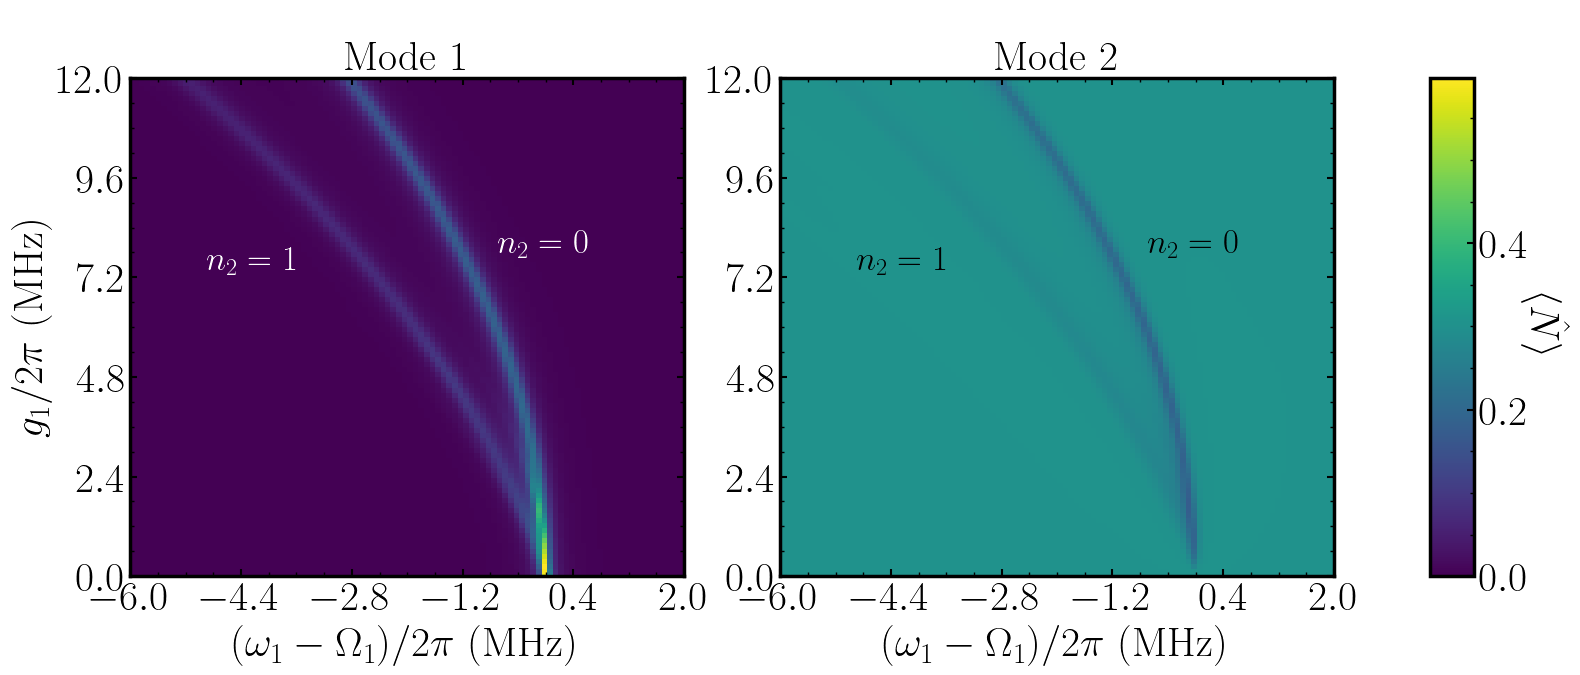

In [ ]:
#import matplotlib.pyplot as plt
#import matplotlib as mpl
#from matplotlib import gridspec

# ---- Figure + GridSpec ----
fig = plt.figure(figsize=(16, 6))

gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[1, 1, 0.08],  
    wspace=0.25
)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_1[3].max(), z_list_1[4].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_1, y_list_1, z_list_1[3],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(x0, xf)
ax0.set_ylim(y0, yf)
ax0.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax0.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax0.set_title(r'Mode 1')

# overlays
ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='white', fontsize=50)
ax0.text(-4.9, 7.4, r"$n_2 = 1$", color='white', fontsize=25)
ax0.text(-0.7, 7.8, r"$n_2 = 0$", color='white', fontsize=25)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_1, y_list_1, z_list_1[4],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(x0, xf)
ax1.set_ylim(y0, yf)
ax1.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax1.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax1.set_title(r'Mode 2')

# overlays
ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='white', fontsize=50)
ax1.text(-4.9, 7.4, r"$n_2 = 1$", color='black', fontsize=25)
ax1.text(-0.7, 7.8, r"$n_2 = 0$", color='black', fontsize=25)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$\langle \hat{N} \rangle$', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_1 + "Figures", "Sim1_Fig04", formats=["pdf"])

plt.show()

### 5) Covariance parameters $C_{12}$, $C_{21}$ and $C_\text{sym}$

Figure not saved.


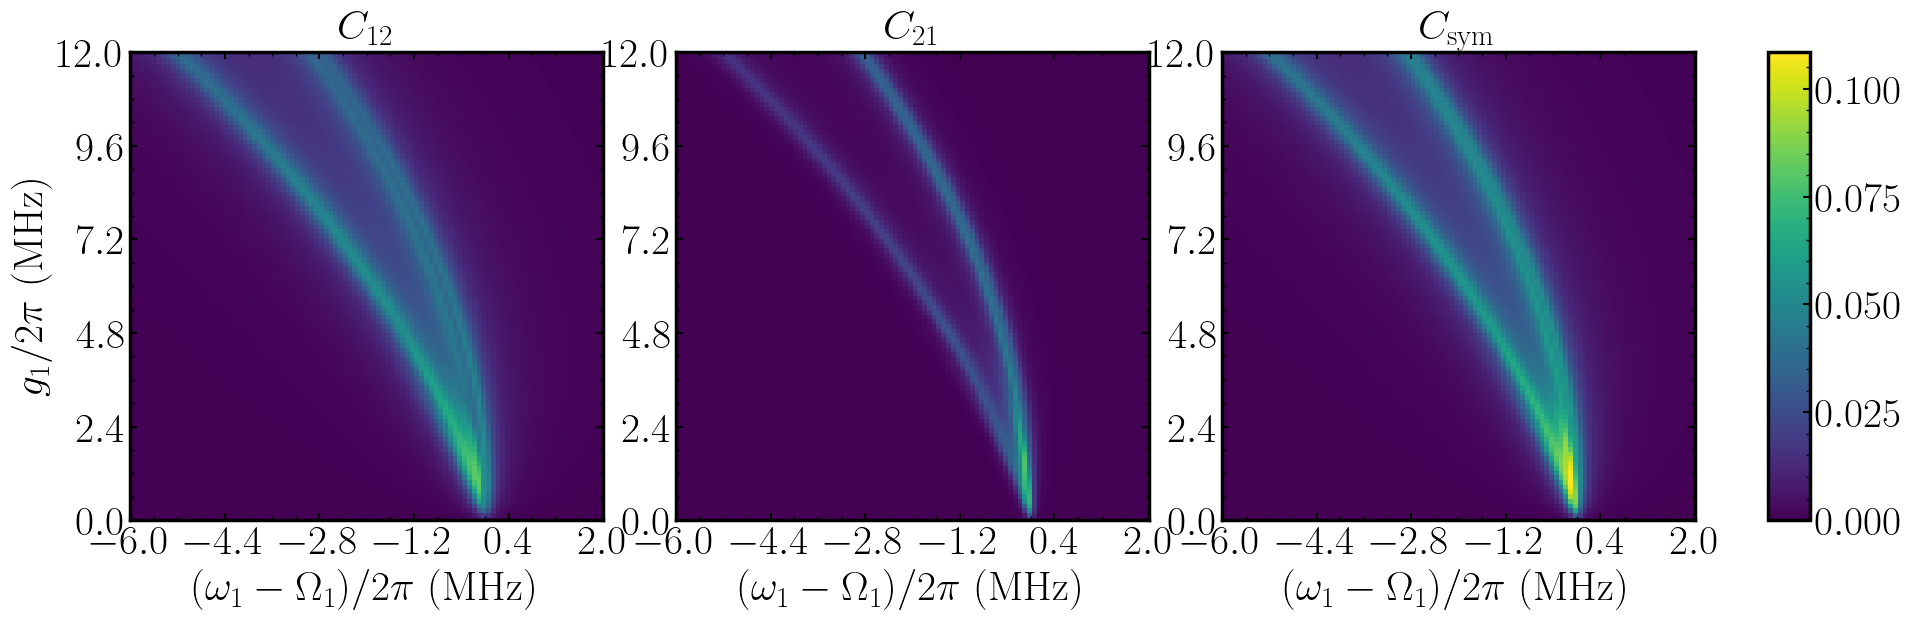

In [ ]:
fig = plt.figure(figsize=(20, 6))

gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.09],  
    wspace=0.2
)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_1[5].max(), z_list_1[6].max(), z_list_1[7].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_1, y_list_1, z_list_1[5],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(x0, xf)
ax0.set_ylim(y0, yf)
ax0.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax0.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax0.set_title(r'$C_{12}$',pad=10)

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_1, y_list_1, z_list_1[6],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(x0, xf)
ax1.set_ylim(y0, yf)
ax1.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax1.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax1.set_title(r'$C_{21}$',pad=10)

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

##############################################################
# ---- Third plot ----
im3 = ax2.pcolormesh(
    x_list_1, y_list_1, z_list_1[7],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax2.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax2.set_xlim(x0, xf)
ax2.set_ylim(y0, yf)
ax2.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax2.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
ax2.set_title(r'$C_\mathrm{sym}$',pad=10)

# overlays
#ax2.text(-7.5, 12.5, r"$\mathbf{c}$", color='black', fontsize=50)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.9
)
save_figure(fig, folder_1 + "Figures", "Sim1_Fig05", formats=["pdf"])

plt.show()

### 6) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2

Figure not saved.


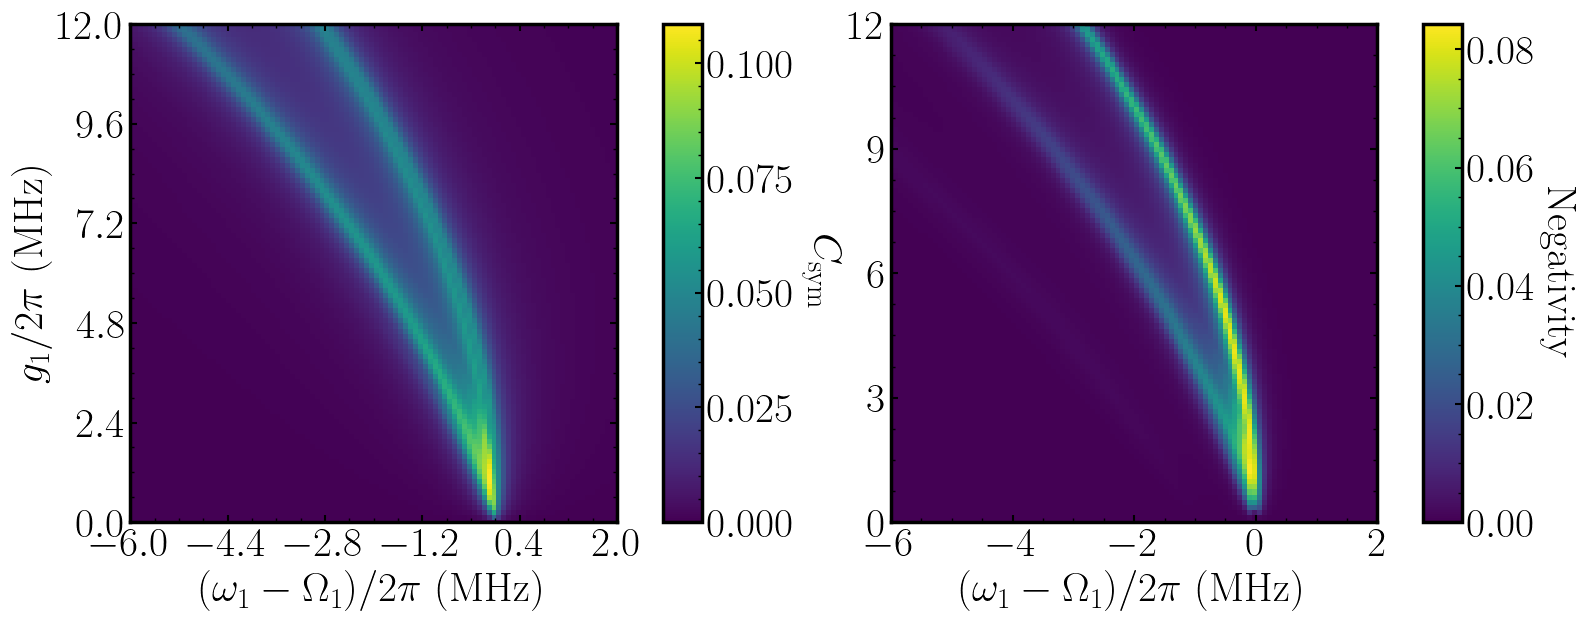

In [ ]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
nrm1 = mpl.colors.Normalize(z_list_1[7].min(), z_list_1[7].max())

im1 = ax0.pcolormesh(
    x_list_1, y_list_1, z_list_1[7],
    cmap=cm.viridis,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(x0, xf)
ax0.set_ylim(y0, yf)
ax0.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax0.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$C_\mathrm{sym}$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(z_list_1[8].min(), z_list_1[8].max())

im2 = ax1.pcolormesh(
    x_list_1, y_list_1, z_list_1[8],
    cmap=cm.viridis,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(x0, xf)
ax1.set_ylim(y0, yf)
ax1.xaxis.set_ticks(arange(x0, xf*1.01, delta_x/4))
ax1.yaxis.set_ticks(arange(y0, yf*1.01, delta_y/4))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'Negativity', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_1 + "Figures", "Sim1_Fig06", formats=["pdf"])

plt.show()

## Simulation 2

In [457]:
folder_2 = "Results/Simulation_2/"
x_list_2, y_list_2, z_list_2 = load_result(folder_2)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

# absA_list,                          #0
# absA_list_2,                        #1
# absB_list,                          #2
# listAux_NumberOp_modeA,             #3
# listAux_NumberOp_modeB,             #4
# listAux_C1,                         #5
# listAux_C2,                         #6
# listAux_Csym,                       #7
# listAux_negativity_modesAB]         #8


Available files:
[0] Results_[2026-04-01]_[02h59m].npy
[1] Results_[2026-04-01]_[02h50m].npy
[2] Results_[2026-04-01]_[02h32m].npy
[3] Results_[2026-04-01]_[01h55m].npy
[4] Results_[2026-03-26]_[01h01m].npy
[5] Results_[2026-03-18]_[11h24m].npy
[6] Results_[2023-08-25]_[10h57m].npy

Loading: Results/Simulation_2\Results_[2026-04-01]_[02h59m].npy



### 1) Colormap for cavity 1 and 2 average field amplitude $g_1 \times g_2 \times \langle\hat{a}_k\rangle_{ss}$

Figure not saved.


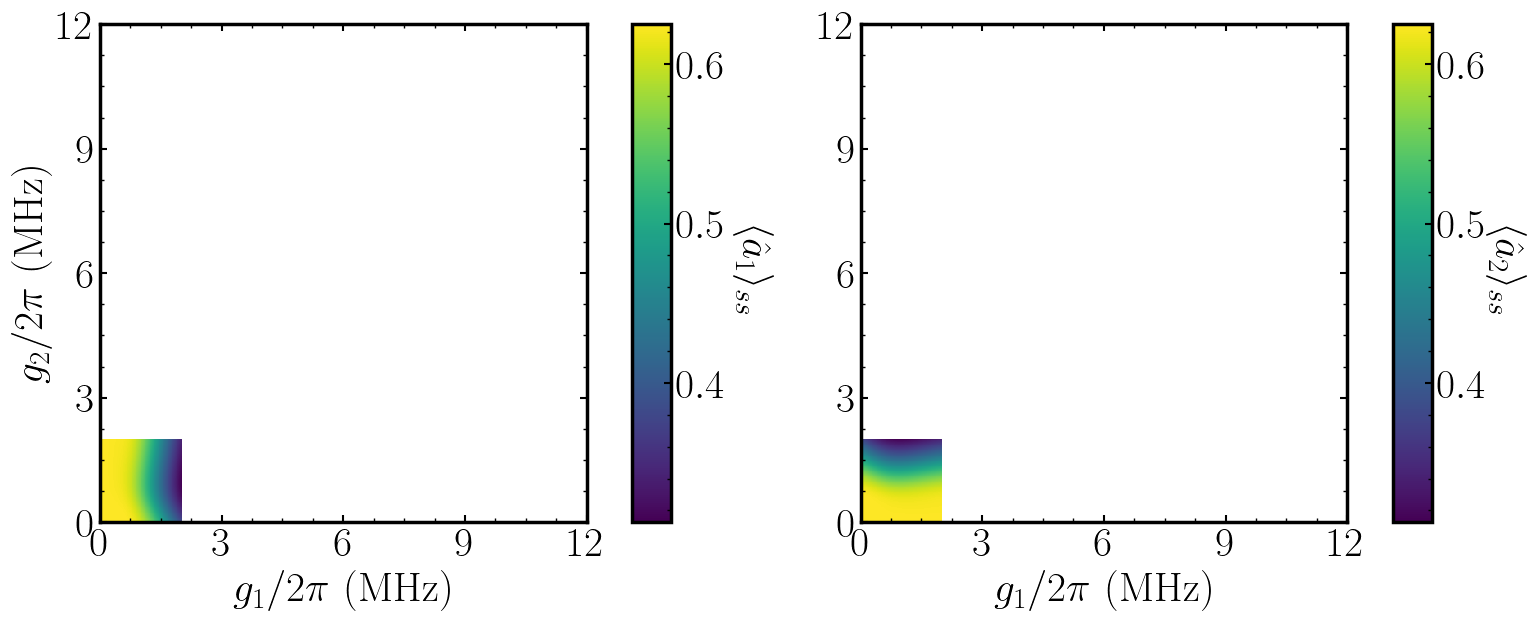

In [458]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
nrm1 = mpl.colors.Normalize(z_list_2[0].min(), z_list_2[0].max())

im1 = ax0.pcolormesh(
    x_list_2, y_list_2, z_list_2[0],
    cmap=cm.viridis,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_2/2\pi$ (MHz)')
ax0.set_xlim(0, 12)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(0, 12.1, 3))
ax0.set_yticks(arange(0, 12.1, 3))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$\langle\hat{a}_1\rangle_{ss}$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(z_list_2[2].min(), z_list_2[2].max())

im2 = ax1.pcolormesh(
    x_list_2, y_list_2, z_list_2[2],
    cmap=cm.viridis,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(0, 12.1, 3))
ax1.set_yticks(arange(0, 12.1, 3))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$\langle\hat{a}_2\rangle_{ss}$', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_2 + "Figures", "Sim2_Fig01", formats=["pdf"])

plt.show()

### 2) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

Figure not saved.


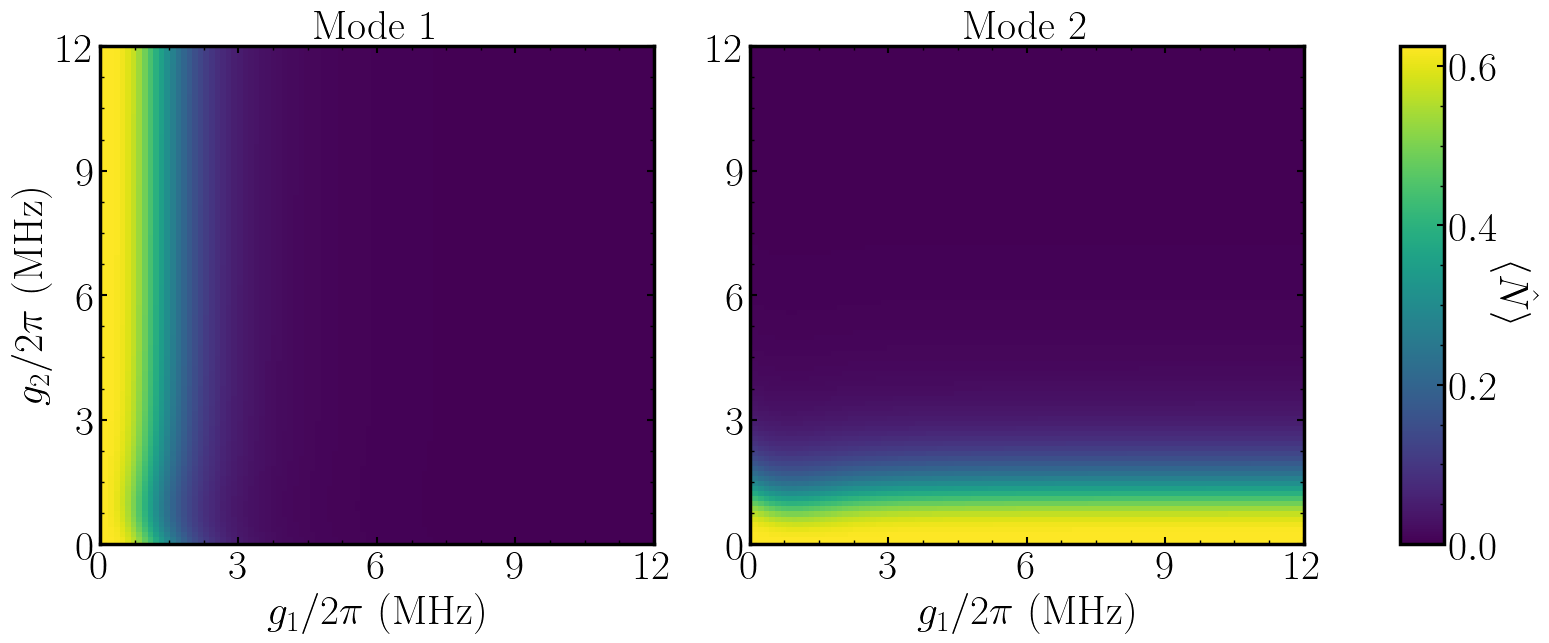

In [453]:
fig = plt.figure(figsize=(16, 6))

gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[1, 1, 0.08],  
    wspace=0.25
)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_2[3].max(), z_list_2[4].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_2, y_list_2, z_list_2[3],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_2/2\pi$ (MHz)')
ax0.set_xlim(0, 12)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(0, 12.1, 3))
ax0.set_yticks(arange(0, 12.1, 3))
ax0.set_title(r'Mode 1')

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='white', fontsize=50)
#ax0.text(-4.9, 7.4, r"$n_2 = 1$", color='white', fontsize=25)
#ax0.text(-0.7, 7.8, r"$n_2 = 0$", color='white', fontsize=25)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_2, y_list_2, z_list_2[4],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(0, 12.1, 3))
ax1.set_yticks(arange(0, 12.1, 3))
ax1.set_title(r'Mode 2')

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='white', fontsize=50)
#ax1.text(-4.9, 7.4, r"$n_2 = 1$", color='black', fontsize=25)
#ax1.text(-0.7, 7.8, r"$n_2 = 0$", color='black', fontsize=25)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$\langle \hat{N} \rangle$', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_2 + "Figures", "Sim2_Fig02", formats=["pdf"])

plt.show()

### 3) Covariance parameters $C_{12}$, $C_{21}$ and $C_\text{sym}$

Figure not saved.


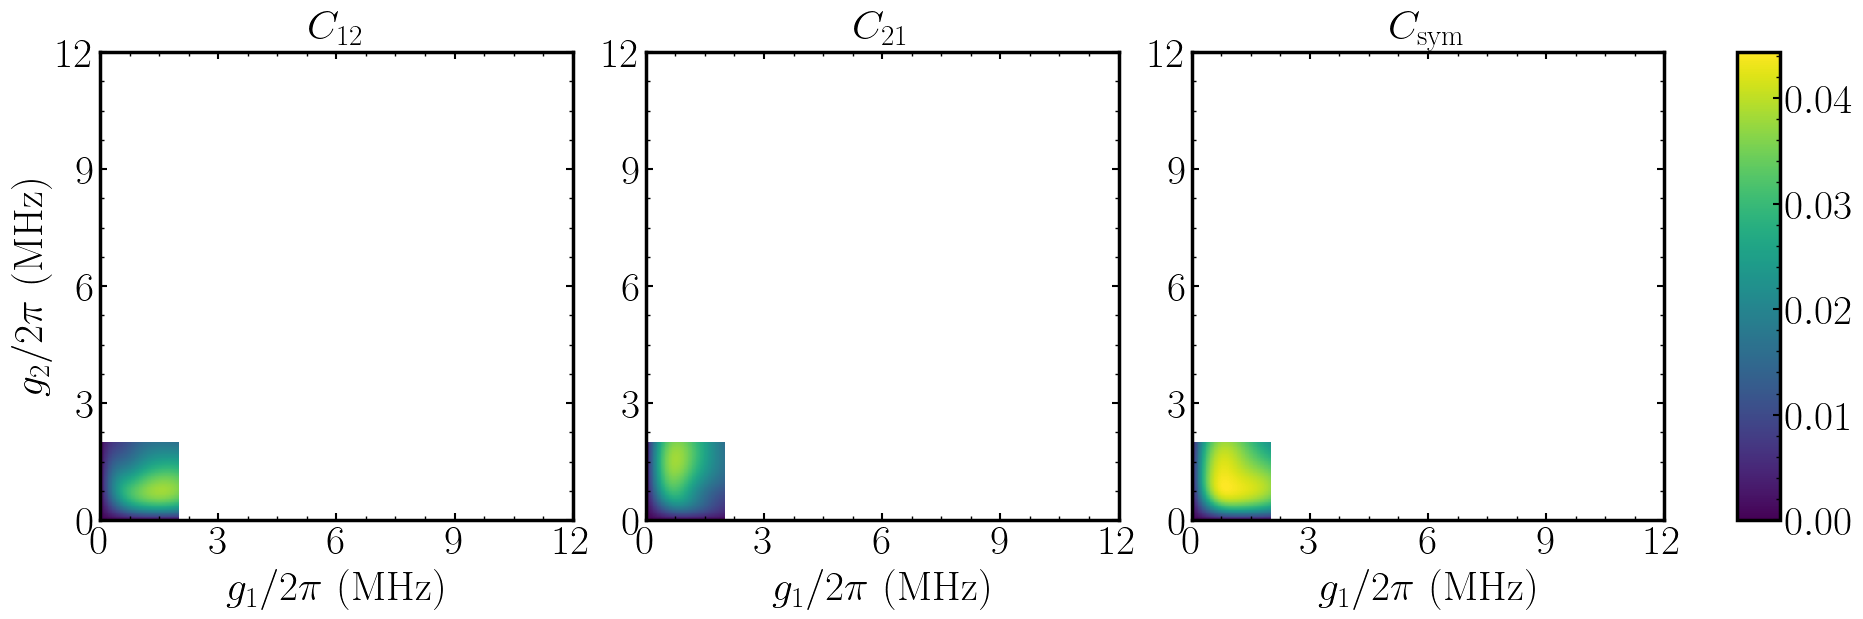

In [459]:
fig = plt.figure(figsize=(20, 6))

gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.09],  
    wspace=0.2
)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_2[5].max(), z_list_2[6].max(), z_list_2[7].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_2, y_list_2, z_list_2[5],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_2/2\pi$ (MHz)')
ax0.set_xlim(0, 12)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(0, 12.1, 3))
ax0.set_yticks(arange(0, 12.1, 3))
ax0.set_title(r'$C_{12}$',pad=10)

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_2, y_list_2, z_list_2[6],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(0, 12.1, 3))
ax1.set_yticks(arange(0, 12.1, 3))
ax1.set_title(r'$C_{21}$',pad=10)

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

##############################################################
# ---- Third plot ----
im3 = ax2.pcolormesh(
    x_list_2, y_list_2, z_list_2[7],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax2.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 12)
ax2.set_xticks(arange(0, 12.1, 3))
ax2.set_yticks(arange(0, 12.1, 3))
ax2.set_title(r'$C_\mathrm{sym}$',pad=10)

# overlays
#ax2.text(-7.5, 12.5, r"$\mathbf{c}$", color='black', fontsize=50)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.9
)
save_figure(fig, folder_2 + "Figures", "Sim2_Fig03", formats=["pdf"])

plt.show()

### 4) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2

Figure not saved.


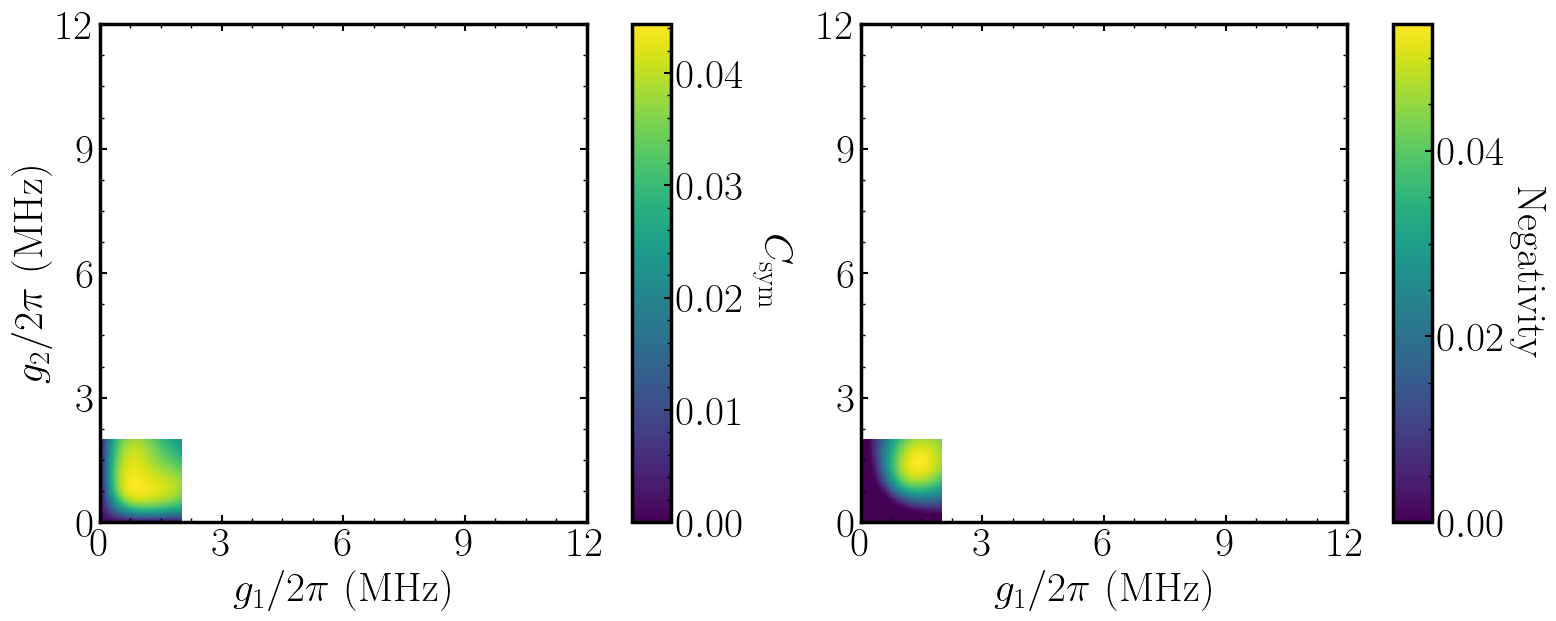

In [460]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
i = 7
nrm1 = mpl.colors.Normalize(z_list_2[i].min(), z_list_2[i].max())

im1 = ax0.pcolormesh(
    x_list_2, y_list_2, z_list_2[i],
    cmap=cm.viridis,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_2/2\pi$ (MHz)')
ax0.set_xlim(0, 12)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(0, 12.1, 3))
ax0.set_yticks(arange(0, 12.1, 3))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$C_\mathrm{sym}$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(z_list_2[8].min(), z_list_2[8].max())

im2 = ax1.pcolormesh(
    x_list_2, y_list_2, z_list_2[8],
    cmap=cm.viridis,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$g_1/2\pi$ (MHz)')
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(0, 12.1, 3))
ax1.set_yticks(arange(0, 12.1, 3))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'Negativity', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_2 + "Figures", "Sim2_Fig04", formats=["pdf"])

plt.show()

### 5) 2nd order Correlation $g^{(2)}(0)$ colormap

Figure not saved.


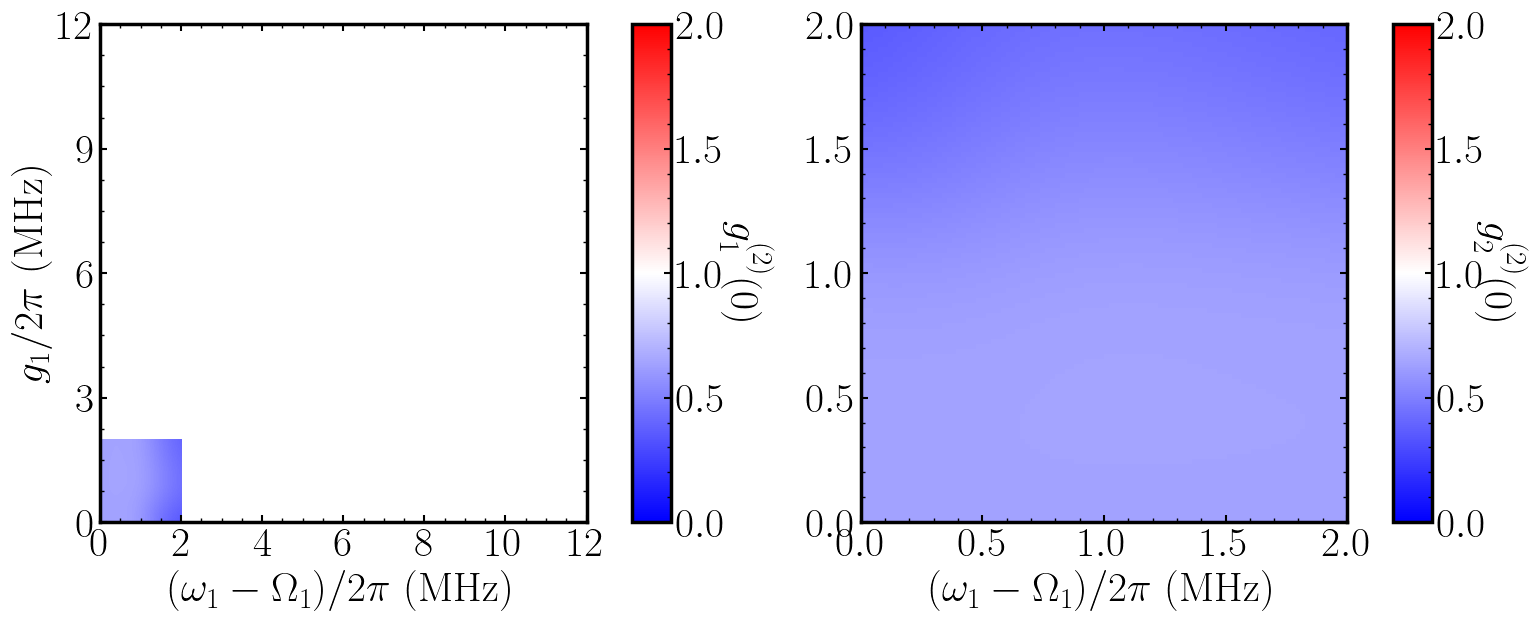

In [464]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
i = 9
nrm1 = mpl.colors.Normalize(0,2)

im1 = ax0.pcolormesh(
    x_list_2, y_list_2, z_list_2[i],
    cmap=cm.bwr,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(0, 12)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(0, 12.1, 2))
ax0.set_yticks(arange(0, 12.1, 3))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$g_1^{(2)}(0)$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(0, 2)

im2 = ax1.pcolormesh(
    x_list_2, y_list_2, z_list_2[i+1],
    cmap=cm.bwr,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_xticks(arange(0, 2.1, 0.5))
ax1.set_yticks(arange(0, 2.1, 0.5))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$g_2^{(2)}(0)$', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_2 + "Figures", "Sim2_Fig05", formats=["pdf"])

plt.show()

## Simulation 3

In [266]:
folder_3 = "Results/Simulation_3/"
x_list_3, y_list_3, z_list_3 = load_result(folder_3)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

# absA_list,                          #0
# absA_list_2,                        #1
# absB_list,                          #2
# listAux_NumberOp_modeA,             #3
# listAux_NumberOp_modeB,             #4
# listAux_C1,                         #5
# listAux_C2,                         #6
# listAux_Csym,                       #7
# listAux_negativity_modesAB]         #8


Available files:
[0] Results_[2026-03-25]_[13h50m].npy
[1] Results_[2026-03-23]_[17h55m].npy
[2] Results_[2023-08-25]_[11h05m].npy

Loading: Results/Simulation_3\Results_[2026-03-25]_[13h50m].npy



### 1) Colormap for cavity 1 and 2 average field amplitude $g_1 \times g_2 \times \langle\hat{a}_k\rangle_{ss}$

Figure not saved.


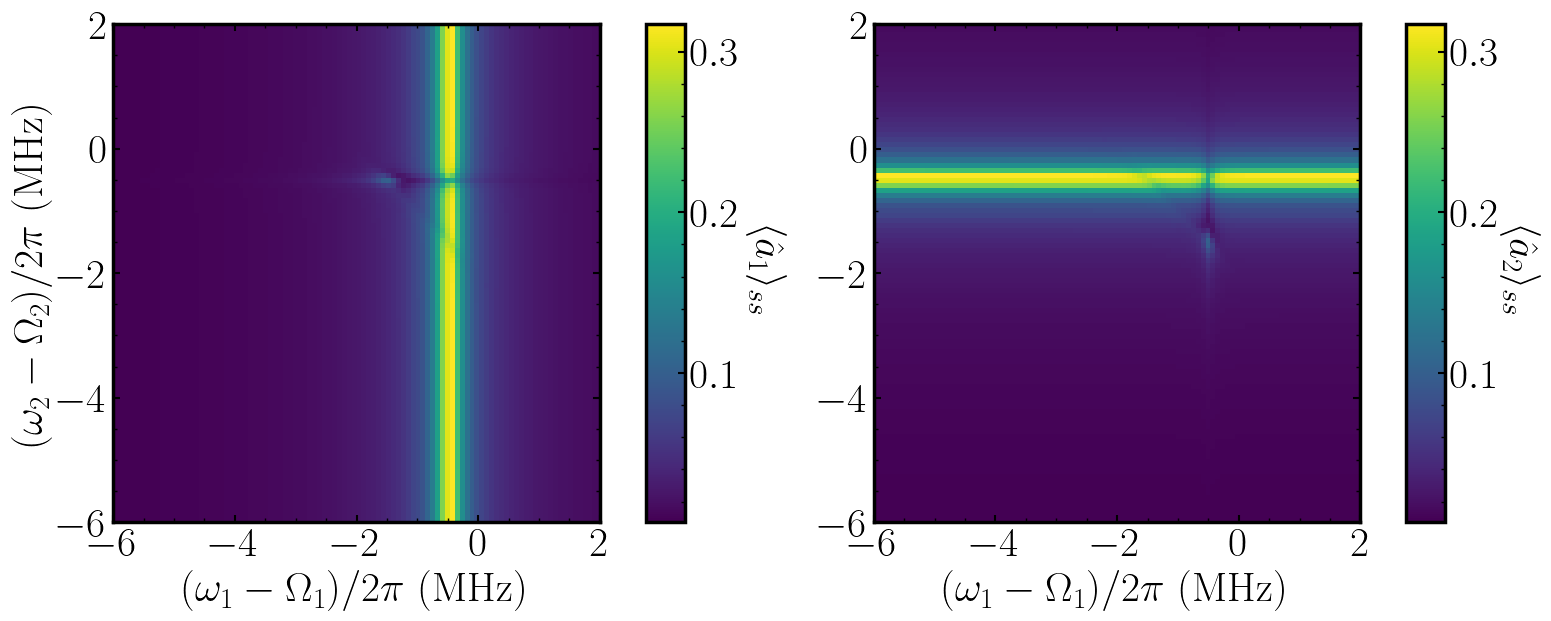

In [267]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
nrm1 = mpl.colors.Normalize(z_list_3[0].min(), z_list_3[0].max())

im1 = ax0.pcolormesh(
    x_list_3, y_list_3, z_list_3[0],
    cmap=cm.viridis,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$(\omega_2 - \Omega_2)/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(-6, 2)

ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(-6, 2.1, 2))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$\langle\hat{a}_1\rangle_{ss}$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(z_list_3[2].min(), z_list_3[2].max())

im2 = ax1.pcolormesh(
    x_list_3, y_list_3, z_list_3[2],
    cmap=cm.viridis,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(-6, 2)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(-6, 2.1, 2))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$\langle\hat{a}_2\rangle_{ss}$', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_3 + "Figures", "Sim3_Fig01", formats=["pdf"])

plt.show()

### 2) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

Figure not saved.


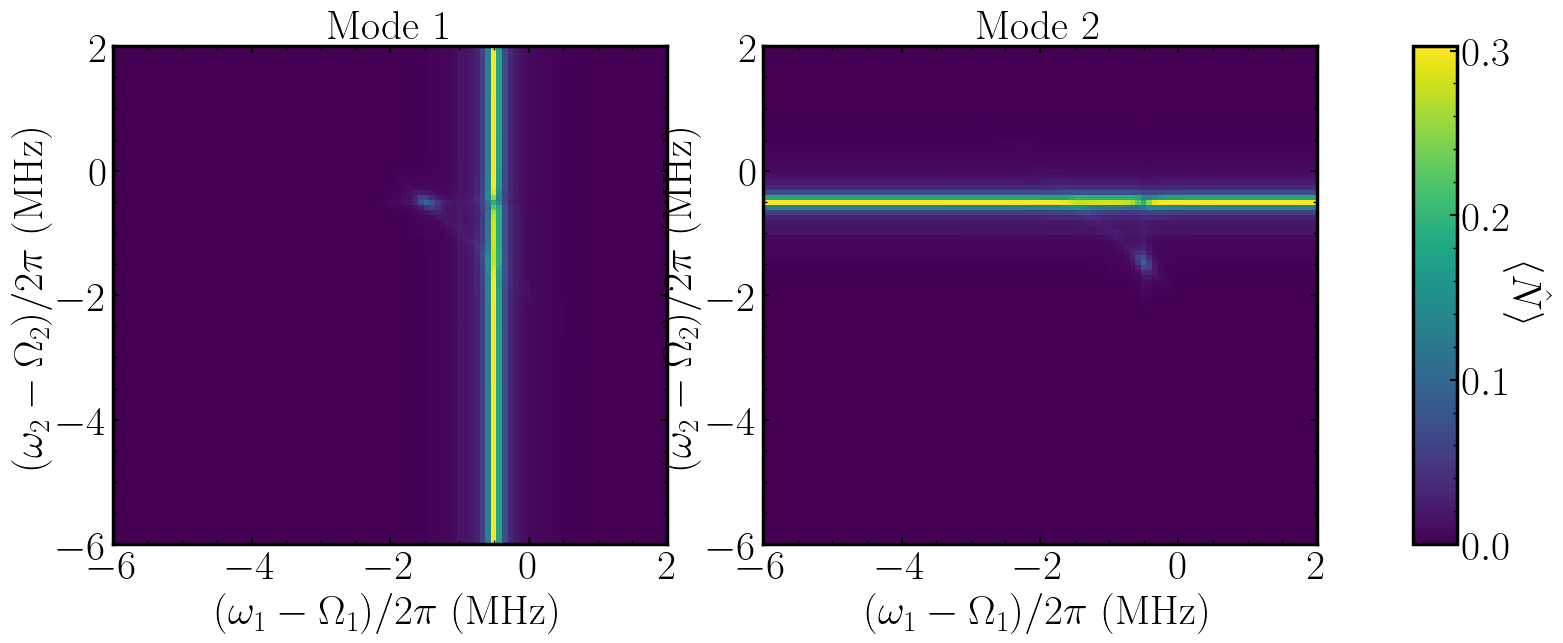

In [268]:
fig = plt.figure(figsize=(16, 6))

gs = gridspec.GridSpec(
    1, 3,
    width_ratios=[1, 1, 0.08],  
    wspace=0.25
)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_3[3].max(), z_list_3[4].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_3, y_list_3, z_list_3[3],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$(\omega_2 - \Omega_2)/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(-6, 2)
ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(-6, 2.1, 2))
ax0.set_title(r'Mode 1')

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='white', fontsize=50)
#ax0.text(-4.9, 7.4, r"$n_2 = 1$", color='white', fontsize=25)
#ax0.text(-0.7, 7.8, r"$n_2 = 0$", color='white', fontsize=25)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_3, y_list_3, z_list_3[4],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_ylabel(r'$(\omega_2 - \Omega_2)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(-6, 2)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(-6, 2.1, 2))
ax1.set_title(r'Mode 2')

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='white', fontsize=50)
#ax1.text(-4.9, 7.4, r"$n_2 = 1$", color='black', fontsize=25)
#ax1.text(-0.7, 7.8, r"$n_2 = 0$", color='black', fontsize=25)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$\langle \hat{N} \rangle$', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_3 + "Figures", "Sim3_Fig02", formats=["pdf"])

plt.show()

### 3) Covariance parameters $C_{12}$, $C_{21}$ and $C_\text{sym}$

Figure not saved.


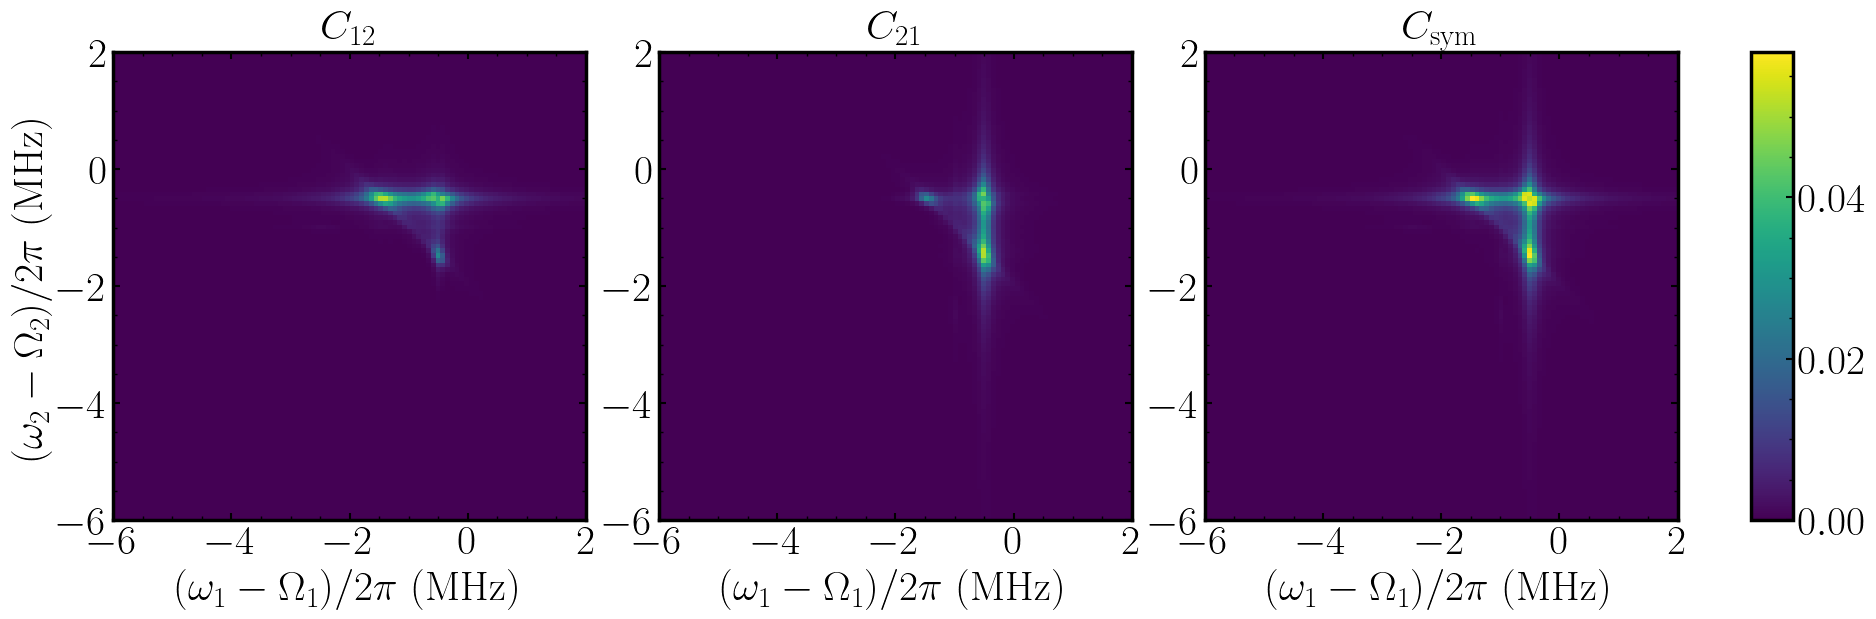

In [269]:
fig = plt.figure(figsize=(20, 6))

gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.09],  
    wspace=0.2
)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_3[5].max(), z_list_3[6].max(), z_list_3[7].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_3, y_list_3, z_list_3[5],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$(\omega_2 - \Omega_2)/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(-6, 2)
ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(-6, 2.1, 2))
ax0.set_title(r'$C_{12}$',pad=10)

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_3, y_list_3, z_list_3[6],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(-6, 2)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(-6, 2.1, 2))
ax1.set_title(r'$C_{21}$',pad=10)

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

##############################################################
# ---- Third plot ----
im3 = ax2.pcolormesh(
    x_list_3, y_list_3, z_list_3[7],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax2.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax2.set_xlim(-6, 2)
ax2.set_ylim(-6, 2)
ax2.set_xticks(arange(-6, 2.1, 2))
ax2.set_yticks(arange(-6, 2.1, 2))
ax2.set_title(r'$C_\mathrm{sym}$',pad=10)

# overlays
#ax2.text(-7.5, 12.5, r"$\mathbf{c}$", color='black', fontsize=50)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.9
)
save_figure(fig, folder_3 + "Figures", "Sim3_Fig03", formats=["pdf"])

plt.show()

### 4) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2

Figure not saved.


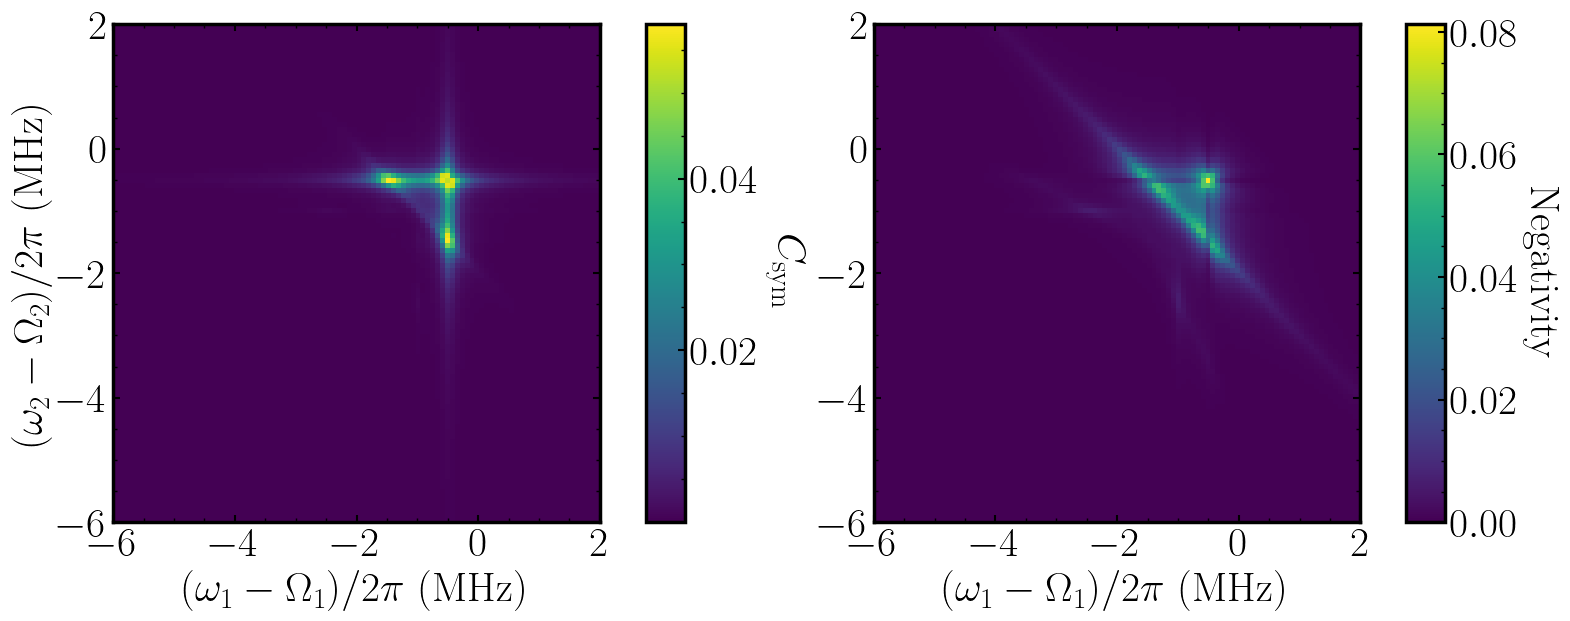

In [270]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
i = 7
nrm1 = mpl.colors.Normalize(z_list_3[i].min(), z_list_3[i].max())

im1 = ax0.pcolormesh(
    x_list_3, y_list_3, z_list_3[i],
    cmap=cm.viridis,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$(\omega_2 - \Omega_2)/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(-6, 2)
ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(-6, 2.1, 2))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$C_\mathrm{sym}$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(z_list_3[8].min(), z_list_3[8].max())

im2 = ax1.pcolormesh(
    x_list_3, y_list_3, z_list_3[8],
    cmap=cm.viridis,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(-6, 2)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(-6, 2.1, 2))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'Negativity', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_3 + "Figures", "Sim3_Fig04", formats=["pdf"])

plt.show()

## Simulation 4

In [406]:
folder_4 = "Results/Simulation_4/"
x_list_4, y_list_4, z_list_4 = load_result(folder_4)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

#absA_list,                          #0
#absA_list_2,                        #1
#absB_list,                          #2
#listAux_NumberOp_modeA,             #3
#listAux_NumberOp_modeB,             #4
#listAux_populationLevel0_modeA,     #5
#listAux_populationLevel1_modeA,     #6
#listAux_populationLevel2_modeA,     #7
#listAux_populationLevel3_modeA,     #8
#listAux_populationLevel4_modeA,     #9
#listAux_populationLevel0_modeB,     #10
#listAux_populationLevel1_modeB,     #11
#listAux_populationLevel2_modeB,     #12
#listAux_populationLevel3_modeB,     #13
#listAux_populationLevel4_modeB]     #14


Available files:
[0] Results_[2026-04-01]_[01h24m].npy
[1] Results_[2026-04-01]_[01h19m].npy
[2] Results_[2026-04-01]_[01h05m].npy
[3] Results_[2026-04-01]_[00h57m].npy
[4] Results_[2026-04-01]_[00h52m].npy
[5] Results_[2026-04-01]_[00h21m].npy
[6] Results_[2026-04-01]_[00h16m].npy
[7] Results_[2026-03-26]_[16h52m].npy
[8] Results_[2026-03-26]_[16h50m].npy
[9] Results_[2026-03-26]_[16h48m].npy
[10] Results_[2026-03-26]_[16h47m].npy
[11] Results_[2026-03-26]_[16h40m].npy
[12] Results_[2026-03-26]_[16h37m].npy
[13] Results_[2026-03-26]_[16h36m].npy
[14] Results_[2026-03-26]_[16h34m].npy
[15] Results_[2026-03-26]_[16h28m].npy
[16] Results_[2026-03-26]_[16h25m].npy
[17] Results_[2026-03-26]_[16h22m].npy
[18] Results_[2026-03-26]_[16h20m].npy
[19] Results_[2026-03-26]_[16h15m].npy
[20] Results_N4_[2026-03-26]_[15h44m].npy
[21] Results_[2026-03-26]_[11h28m].npy
[22] Results_[2026-03-25]_[14h12m].npy
[23] Results_[2026-03-24]_[01h37m].npy
[24] Results_[2023-08-26]_[08h19m].npy

Loading: Resu

### 1) Population colormap for the first three levels for cavity 1

Figure not saved.


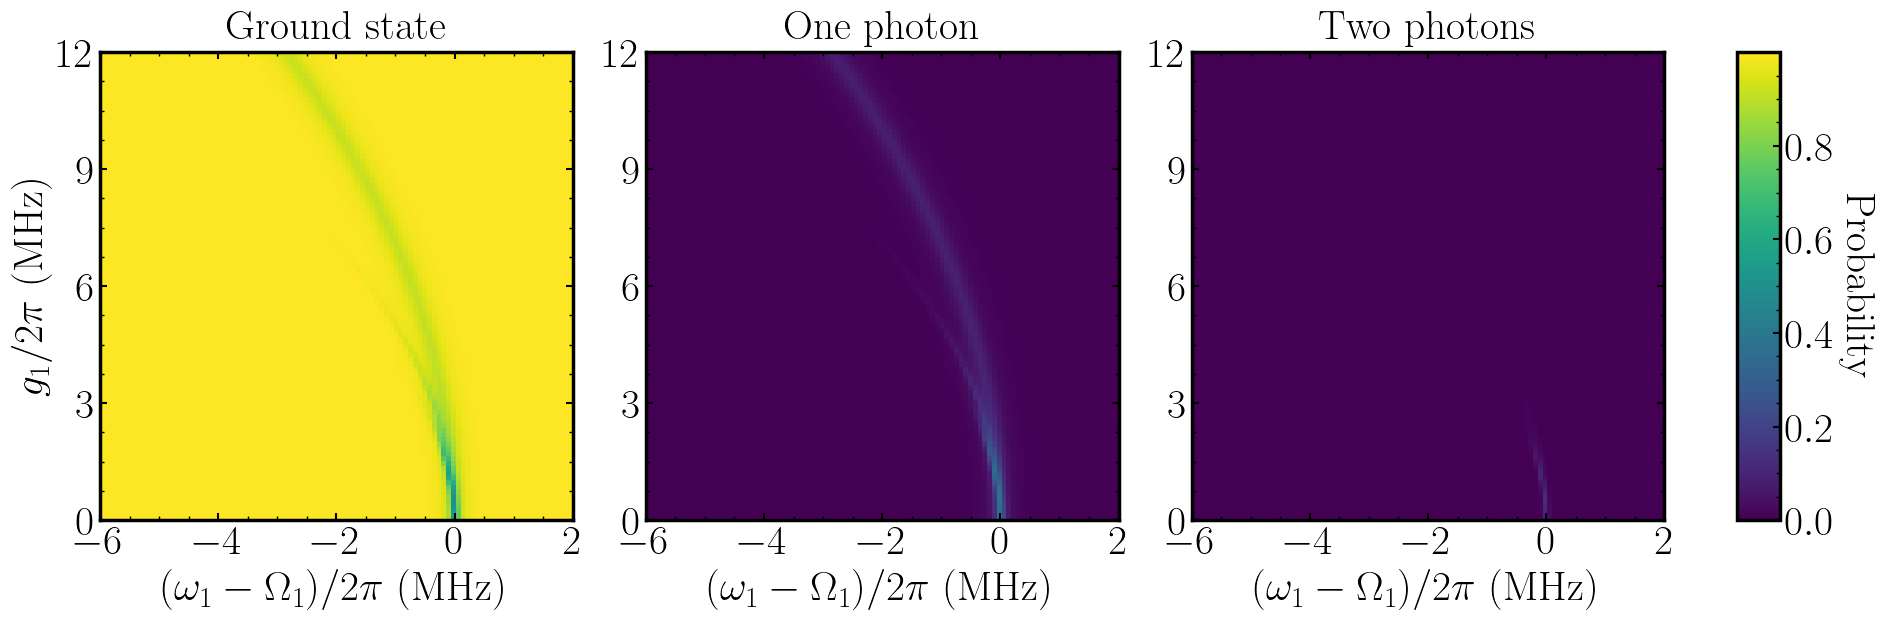

In [407]:
fig = plt.figure(figsize=(20, 6))

gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.09],  
    wspace=0.2
)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_4[5].max(), z_list_4[6].max(), z_list_4[7].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_4, y_list_4, z_list_4[5],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(0, 12.1, 3))
ax0.set_title(r'Ground state',pad=10)

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_4, y_list_4, z_list_4[6],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(0, 12.1, 3))
ax1.set_title(r'One photon',pad=10)

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

##############################################################
# ---- Third plot ----
im3 = ax2.pcolormesh(
    x_list_4, y_list_4, z_list_4[7],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax2.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax2.set_xlim(-6, 2)
ax2.set_ylim(0, 12)
ax2.set_xticks(arange(-6, 2.1, 2))
ax2.set_yticks(arange(0, 12.1, 3))
ax2.set_title(r'Two photons',pad=10)

# overlays
#ax2.text(-7.5, 12.5, r"$\mathbf{c}$", color='black', fontsize=50)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'Probability', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.9
)
save_figure(fig, folder_4 + "Figures", "Sim4_Fig01", formats=["pdf"])

plt.show()

### 2) Population colormap for the first three levels for cavity 2

Figure not saved.


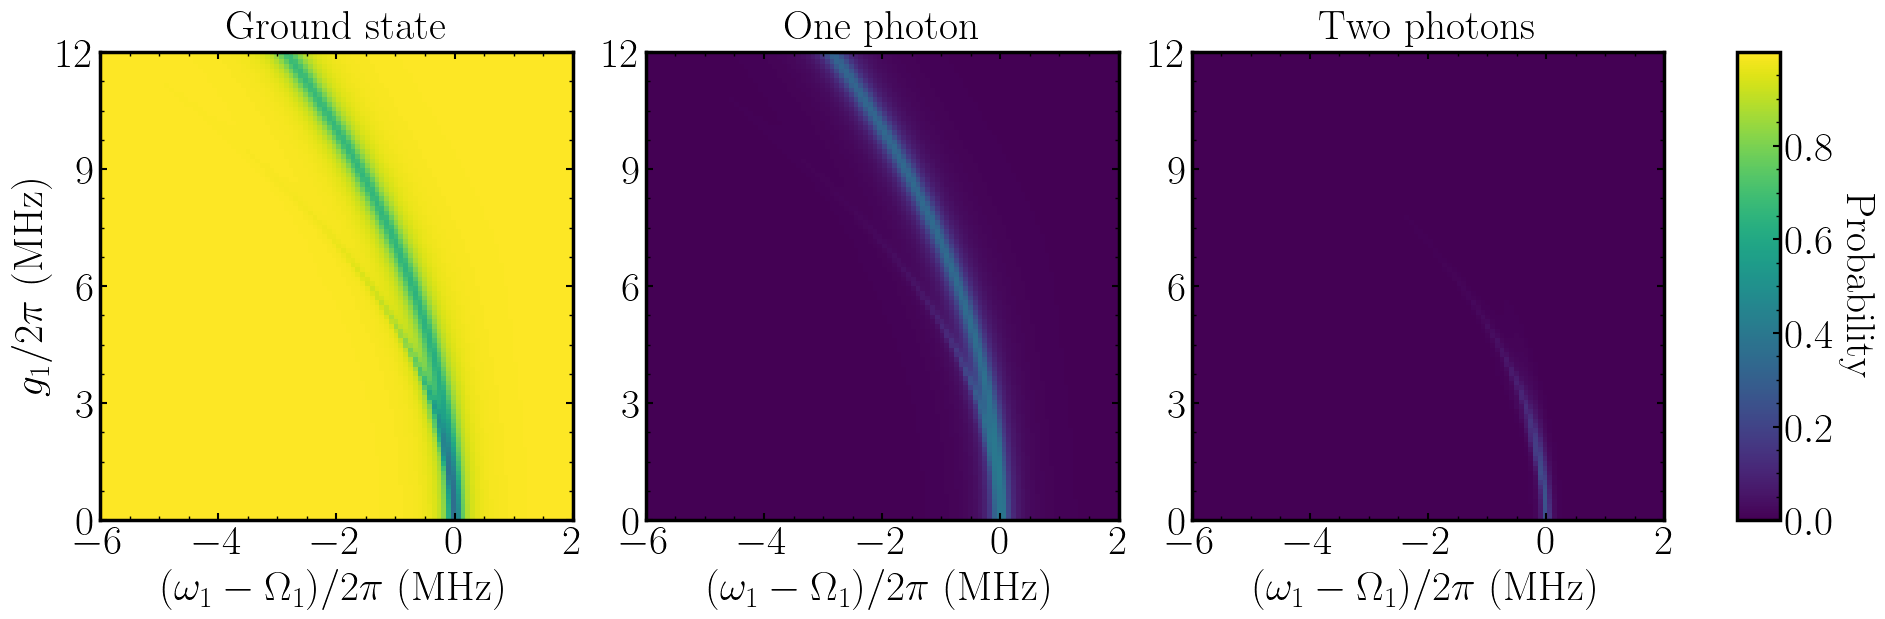

In [408]:
fig = plt.figure(figsize=(20, 6))

gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 0.09],  
    wspace=0.2
)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # colorbar axis

##############################################################
# ---- Shared normalization ----
vmin = 0
vmax = max(z_list_4[8].max(), z_list_4[9].max(), z_list_4[10].max())
nrm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

##############################################################
# ---- First plot ----
im1 = ax0.pcolormesh(
    x_list_4, y_list_4, z_list_4[8],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(0, 12.1, 3))
ax0.set_title(r'Ground state',pad=10)

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

##############################################################
# ---- Second plot ----
im2 = ax1.pcolormesh(
    x_list_4, y_list_4, z_list_4[9],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(0, 12.1, 3))
ax1.set_title(r'One photon',pad=10)

# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

##############################################################
# ---- Third plot ----
im3 = ax2.pcolormesh(
    x_list_4, y_list_4, z_list_4[10],
    cmap=cm.viridis,
    norm=nrm,
    shading='auto'
)
ax2.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax2.set_xlim(-6, 2)
ax2.set_ylim(0, 12)
ax2.set_xticks(arange(-6, 2.1, 2))
ax2.set_yticks(arange(0, 12.1, 3))
ax2.set_title(r'Two photons',pad=10)

# overlays
#ax2.text(-7.5, 12.5, r"$\mathbf{c}$", color='black', fontsize=50)

##############################################################
# ---- Colorbar ----
cbar = fig.colorbar(im1, cax=cax)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'Probability', rotation=270, labelpad=30, fontsize=fs)

##############################################################
# ---- Final spacing tweak ----
plt.subplots_adjust(
    left=0.08,
    right=0.92,
    bottom=0.12,
    top=0.9
)
save_figure(fig, folder_4 + "Figures", "Sim4_Fig02", formats=["pdf"])

plt.show()

### 2) Photon blockade effect at cavity 1 due to cavity 2

Figure not saved.


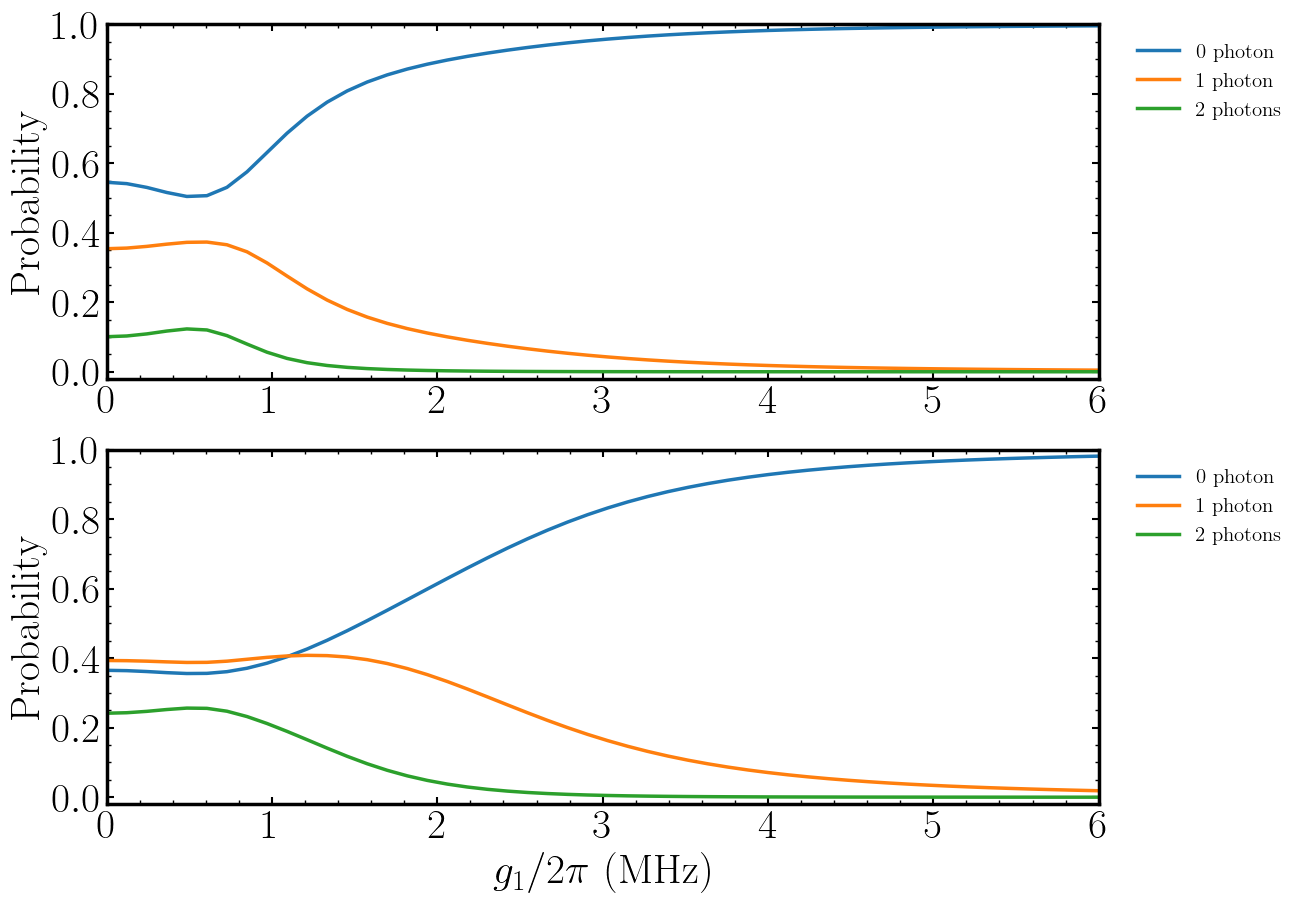

In [409]:
k = argmin(abs(array(x_list_4))) # closest to resonance

p0_A = array([arr[k] for arr in z_list_4[5]])
p1_A = array([arr[k] for arr in z_list_4[6]])
p2_A = array([arr[k] for arr in z_list_4[7]])
#p3_A = array([arr[k] for arr in z_list_4[8]])

p0_B = array([arr[k] for arr in z_list_4[8]])
p1_B = array([arr[k] for arr in z_list_4[9]])
p2_B = array([arr[k] for arr in z_list_4[10]])
#p3_B = array([arr[k] for arr in z_list_4[12]])


fig, axes = plt.subplots(2, 1, figsize=(16, 10))
##############################################################
axes[0].plot(y_list_4, p0_A, linestyle='-', label=r'0 photon')
axes[0].plot(y_list_4, p1_A, linestyle='-', label=r'1 photon')
axes[0].plot(y_list_4, p2_A, linestyle='-', label=r'2 photons')
#axes[0].plot(y_list_4, p3_A, linestyle='-', label=r'3 photons')
##############################################################

axes[0].set_ylabel(r'Probability')
#axes[0].axvspan(2, 5, alpha=0.1, color='gray', label=r'Resonance region')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

axes[0].set_xlim(0, 6)
axes[0].set_ylim(-0.02, 1)

start, end = axes[0].get_xlim()
axes[0].xaxis.set_ticks(arange(start, end+1, 1))
axes[0].yaxis.set_ticks(arange(0, 1.1, 0.2))

##############################################################
axes[1].plot(y_list_4, p0_B, linestyle='-', label=r'0 photon')
axes[1].plot(y_list_4, p1_B, linestyle='-', label=r'1 photon')
axes[1].plot(y_list_4, p2_B, linestyle='-', label=r'2 photons')
#axes[1].plot(y_list_4, p3_B, linestyle='-', label=r'3 photons')
##############################################################
axes[1].set_ylabel(r'Probability')
axes[1].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

axes[1].set_xlim(0, 6)
axes[1].set_ylim(-0.02, 1)

start, end = axes[1].get_xlim()
axes[1].xaxis.set_ticks(arange(start, end+1, 1))
axes[1].yaxis.set_ticks(arange(0, 1.1, 0.2))

##############################################################
#axes[0].text(-7.5, 1, r"$\mathbf{a}$", color='black', fontsize=50)
#axes[1].text(-7.5, 1, r"$\mathbf{b}$", color='black', fontsize=50)
##############################################################
# ---- Global spacing ----
plt.subplots_adjust(
    left=0.08,
    right=0.7,
    bottom=0.12,
    top=0.9,
    wspace=0.3   # spacing between the TWO plots only
)
save_figure(fig, folder_4 + "Figures", "Sim1_Fig03", formats=["pdf"])

plt.show()


### 3) 2nd order Correlation $g^{(2)}(0)$ colormap

Figure not saved.


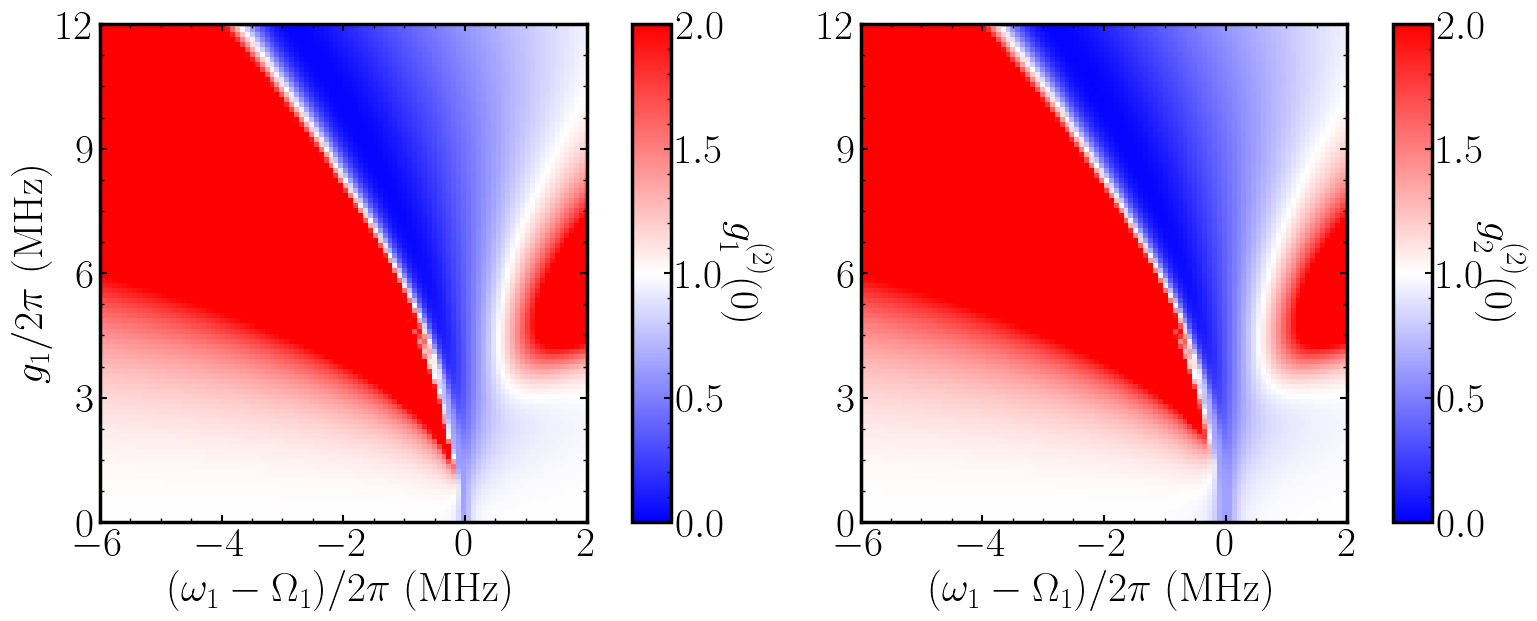

In [410]:
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(
    1, 5,
    width_ratios=[1, 0.08,0.2, 1, 0.08],  
    wspace=0.2
)

ax0  = fig.add_subplot(gs[0])
cax1 = fig.add_subplot(gs[1])
ax1  = fig.add_subplot(gs[3])
cax2 = fig.add_subplot(gs[4])  

##############################################################
i = 11
nrm1 = mpl.colors.Normalize(0,2)

im1 = ax0.pcolormesh(
    x_list_4, y_list_4, z_list_4[i],
    cmap=cm.bwr,
    norm=nrm1,
    shading='auto'
)
ax0.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax0.set_ylabel(r'$g_1/2\pi$ (MHz)')
ax0.set_xlim(-6, 2)
ax0.set_ylim(0, 12)
ax0.set_xticks(arange(-6, 2.1, 2))
ax0.set_yticks(arange(0, 12.1, 3))

# overlays
#ax0.text(-7.5, 12.5, r"$\mathbf{a}$", color='black', fontsize=50)

cbar = fig.colorbar(im1, cax=cax1)

cbar.set_label(
    r'$g_1^{(2)}(0)$',
    rotation=270,
    labelpad=35
)
##############################################################
nrm2 = mpl.colors.Normalize(0, 2)

im2 = ax1.pcolormesh(
    x_list_4, y_list_4, z_list_4[i+1],
    cmap=cm.bwr,
    norm=nrm2,
    shading='auto'
)
ax1.set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
ax1.set_xlim(-6, 2)
ax1.set_ylim(0, 12)
ax1.set_xticks(arange(-6, 2.1, 2))
ax1.set_yticks(arange(0, 12.1, 3))
# overlays
#ax1.text(-7.5, 12.5, r"$\mathbf{b}$", color='black', fontsize=50)

cbar = fig.colorbar(im2, cax=cax2)

cbar.ax.tick_params(labelsize=ls)
cbar.set_label(r'$g_2^{(2)}(0)$', 
               rotation=270, 
               labelpad=30)
##############################################################
plt.subplots_adjust(
    left=0.08,
    right=0.82,
    bottom=0.12,
    top=0.95
)
save_figure(fig, folder_4 + "Figures", "Sim4_Fig03", formats=["pdf"])

plt.show()

## Simulation 5

### 1) Scatter plot Negavitiy vs $C_\text{sym}$ - Sample data from simulation 1

In [414]:
folder_1 = "Results/Simulation_1/"
x_list_1, y_list_1, z_list_1 = load_result(folder_1)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

# absA_list,                          #0
# absA_list_2,                        #1
# absB_list,                          #2
# listAux_NumberOp_modeA,             #3
# listAux_NumberOp_modeB,             #4
# listAux_C1,                         #5
# listAux_C2,                         #6
# listAux_Csym,                       #7
# listAux_negativity_modesAB]         #8



Available files:
[0] Results_[2026-03-25]_[15h53m].npy
[1] Results_[2026-03-25]_[14h58m].npy
[2] Results_[2026-03-25]_[14h12m].npy
[3] Results_[2026-03-25]_[13h40m].npy
[4] Results_[2026-03-24]_[01h13m].npy
[5] Results_[2026-03-23]_[17h15m].npy
[6] Results_[2023-08-25]_[10h49m].npy

Loading: Results/Simulation_1\Results_[2026-03-25]_[15h53m].npy



In [529]:
z_list_1[type_idx][y_idx][x_idx]

3.0058925095181464e-05

In [536]:
z_list_1[7][4]

array([2.29621712e-05, 2.32760176e-05, 2.35963435e-05, 2.39233283e-05,
       2.42571581e-05, 2.45980252e-05, 2.49461289e-05, 2.53016754e-05,
       2.56648786e-05, 2.60359598e-05, 2.64151486e-05, 2.68026829e-05,
       2.71988094e-05, 2.76037842e-05, 2.80178727e-05, 2.84413504e-05,
       2.88745036e-05, 2.93176291e-05, 2.97710355e-05, 3.02350435e-05,
       3.07099861e-05, 3.11962097e-05, 3.16940744e-05, 3.22039550e-05,
       3.27262413e-05, 3.32613391e-05, 3.38096709e-05, 3.43716769e-05,
       3.49478156e-05, 3.55385651e-05, 3.61444236e-05, 3.67659108e-05,
       3.74035693e-05, 3.80579649e-05, 3.87296890e-05, 3.94193587e-05,
       4.01276191e-05, 4.08551449e-05, 4.16026411e-05, 4.23708458e-05,
       4.31605313e-05, 4.39725061e-05, 4.48076174e-05, 4.56667528e-05,
       4.65508432e-05, 4.74608648e-05, 4.83978421e-05, 4.93628508e-05,
       5.03570208e-05, 5.13815395e-05, 5.24376554e-05, 5.35266819e-05,
       5.46500016e-05, 5.58090702e-05, 5.70054218e-05, 5.82406734e-05,
      

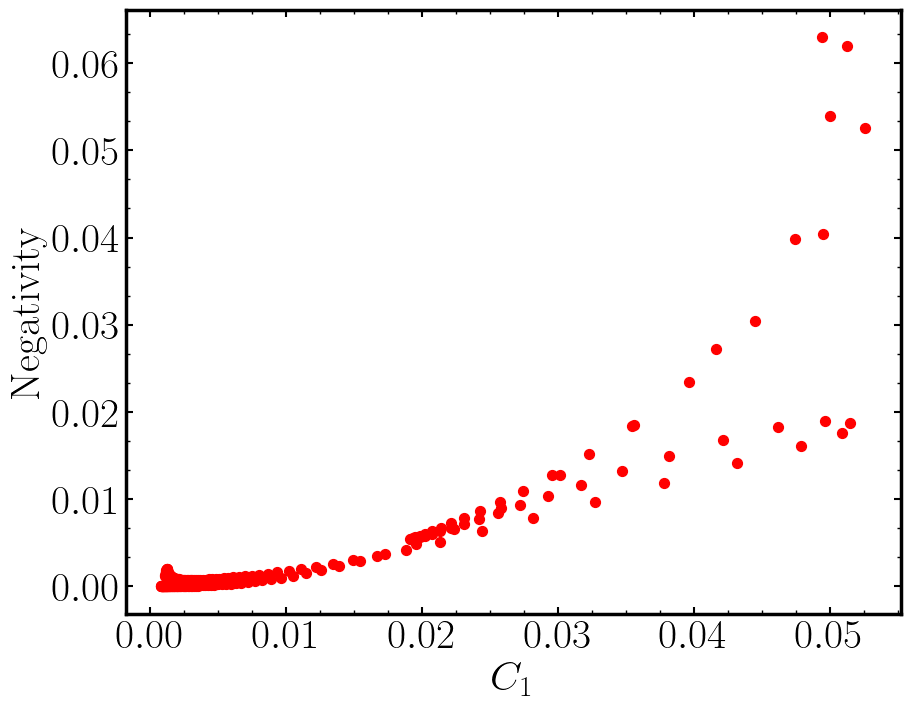

In [531]:
x = []
y = []
for l in range(70,71):
    x.append(z_list_1[7][l])
    y.append(z_list_1[8][l])

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
plt.scatter(x, y, color='red', s=50)
axes.set_xlabel(r'$C_1$', rotation=0, fontsize=fs)
axes.set_ylabel(r'Negativity', rotation=90, fontsize=fs)
axes.tick_params(axis='both', which='major', direction='in', labelsize=ls)
axes.tick_params(axis='both', which='minor', direction='in', labelsize=ls)
#axes.yaxis.set_ticks(arange(0, 12.1, 3))
axes.yaxis.set_ticks_position('both')
axes.xaxis.set_ticks_position('both')
#axes.xaxis.set_ticks(arange(-6, 2.1, 2))
###############################

###############################
axes.yaxis.set_minor_locator(AutoMinorLocator(3))
axes.xaxis.set_minor_locator(AutoMinorLocator(4))
    
axes.xaxis.set_tick_params(length=5)
axes.yaxis.set_tick_params(length=5)

### 2) Scatter plot Negavitiy vs $C_\text{sym}$ - Sample data from simulation 2

In [467]:
folder_2 = "Results/Simulation_2/"
x_list_2, y_list_2, z_list_2 = load_result(folder_2)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

# absA_list,                          #0
# absA_list_2,                        #1
# absB_list,                          #2
# listAux_NumberOp_modeA,             #3
# listAux_NumberOp_modeB,             #4
# listAux_C1,                         #5
# listAux_C2,                         #6
# listAux_Csym,                       #7
# listAux_negativity_modesAB]         #8


Available files:
[0] Results_[2026-04-01]_[02h59m].npy
[1] Results_[2026-04-01]_[02h50m].npy
[2] Results_[2026-04-01]_[02h32m].npy
[3] Results_[2026-04-01]_[01h55m].npy
[4] Results_[2026-03-26]_[01h01m].npy
[5] Results_[2026-03-18]_[11h24m].npy
[6] Results_[2023-08-25]_[10h57m].npy

Loading: Results/Simulation_2\Results_[2026-04-01]_[02h50m].npy



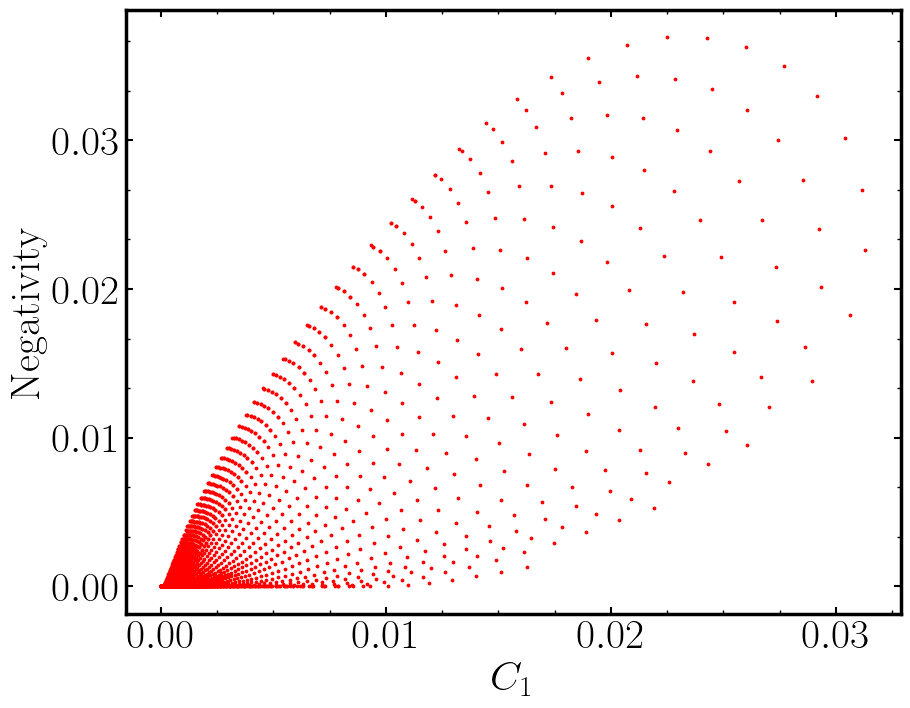

In [469]:
x = []
y = []
for l in range(20,len(y_list_2)):
    x.append(z_list_2[7][l])
    y.append(z_list_2[8][l])

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
plt.scatter(x, y, color='red', s=3)
axes.set_xlabel(r'$C_1$', rotation=0, fontsize=fs)
axes.set_ylabel(r'Negativity', rotation=90, fontsize=fs)
axes.tick_params(axis='both', which='major', direction='in', labelsize=ls)
axes.tick_params(axis='both', which='minor', direction='in', labelsize=ls)
#axes.yaxis.set_ticks(arange(0, 12.1, 3))
axes.yaxis.set_ticks_position('both')
axes.xaxis.set_ticks_position('both')
#axes.xaxis.set_ticks(arange(-6, 2.1, 2))
###############################

###############################
axes.yaxis.set_minor_locator(AutoMinorLocator(3))
axes.xaxis.set_minor_locator(AutoMinorLocator(4))
    
axes.xaxis.set_tick_params(length=5)
axes.yaxis.set_tick_params(length=5)

### 3) Scatter plot Negavitiy vs $C_\text{sym}$ - Sample data from simulation 3

In [422]:
folder_3 = "Results/Simulation_3/"
x_list_3, y_list_3, z_list_3 = load_result(folder_3)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

# absA_list,                          #0
# absA_list_2,                        #1
# absB_list,                          #2
# listAux_NumberOp_modeA,             #3
# listAux_NumberOp_modeB,             #4
# listAux_C1,                         #5
# listAux_C2,                         #6
# listAux_Csym,                       #7
# listAux_negativity_modesAB]         #8


Available files:
[0] Results_[2026-03-26]_[12h53m].npy
[1] Results_[2026-03-25]_[13h50m].npy
[2] Results_[2026-03-23]_[17h55m].npy
[3] Results_[2023-08-25]_[11h05m].npy

Loading: Results/Simulation_3\Results_[2026-03-26]_[12h53m].npy



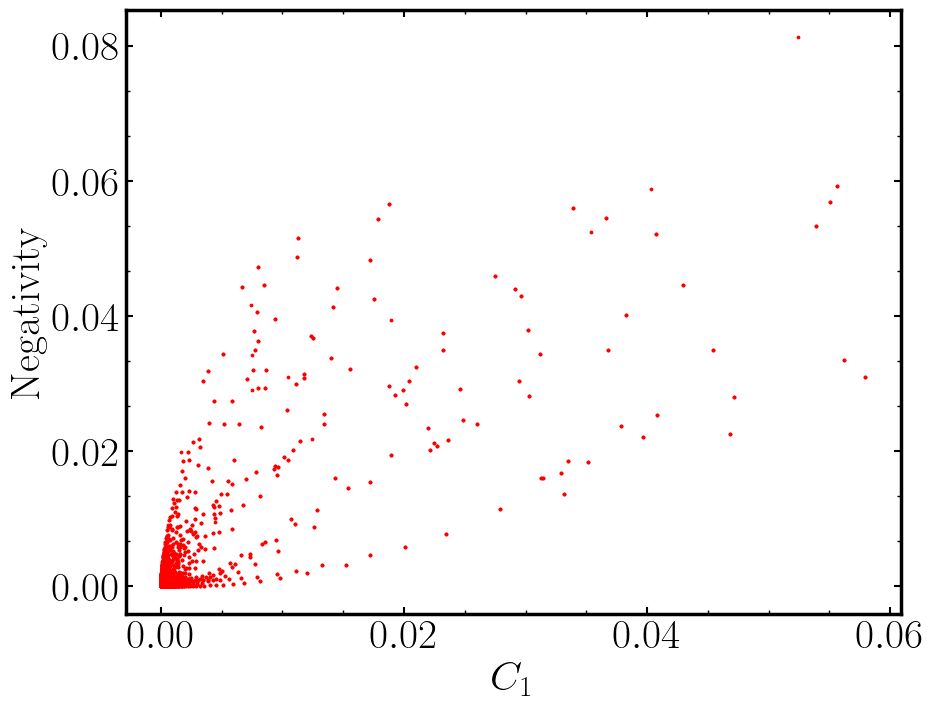

In [429]:
x = []
y = []
for l in range(20,len(y_list_3)):
    x.append(z_list_3[7][l])
    y.append(z_list_3[8][l])


fig, axes = plt.subplots(1, 1, figsize=(10, 8))
plt.scatter(x, y, color='red', s=3)
axes.set_xlabel(r'$C_1$', rotation=0, fontsize=fs)
axes.set_ylabel(r'Negativity', rotation=90, fontsize=fs)
axes.tick_params(axis='both', which='major', direction='in', labelsize=ls)
axes.tick_params(axis='both', which='minor', direction='in', labelsize=ls)
#axes.yaxis.set_ticks(arange(0, 12.1, 3))
axes.yaxis.set_ticks_position('both')
axes.xaxis.set_ticks_position('both')
#axes.xaxis.set_ticks(arange(-6, 2.1, 2))
###############################

###############################
axes.yaxis.set_minor_locator(AutoMinorLocator(3))
axes.xaxis.set_minor_locator(AutoMinorLocator(4))
    
axes.xaxis.set_tick_params(length=5)
axes.yaxis.set_tick_params(length=5)

### 4) Scatter plot Negavitiy vs $C_\text{sym}$ - Sample data from all simulations

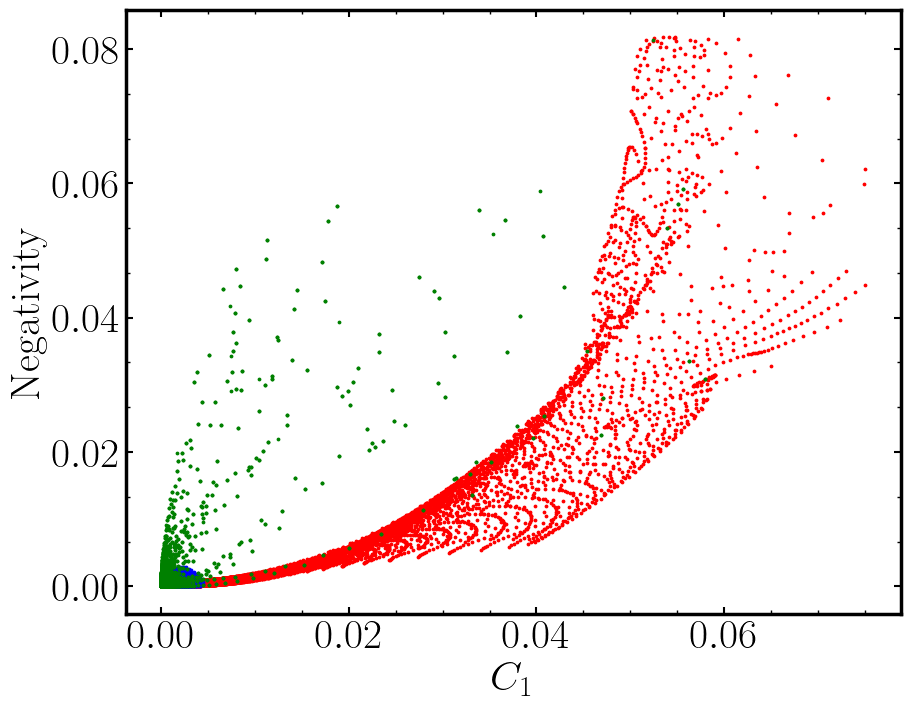

In [470]:
x1 = []
y1 = []
for l in range(20,len(y_list_1)):
    x1.append(z_list_1[7][l])
    y1.append(z_list_1[8][l])

x2 = []
y2 = []
for l in range(50,len(y_list_2)):
    x2.append(z_list_2[7][l])
    y2.append(z_list_2[8][l])

x3 = []
y3 = []
for l in range(20,len(y_list_3)):
    x3.append(z_list_3[7][l])
    y3.append(z_list_3[8][l])

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
plt.scatter(x1, y1, color='red', s=3)
plt.scatter(x2, y2, color='blue', s=3)
plt.scatter(x3, y3, color='green', s=3)
axes.set_xlabel(r'$C_1$', rotation=0, fontsize=fs)
axes.set_ylabel(r'Negativity', rotation=90, fontsize=fs)
axes.tick_params(axis='both', which='major', direction='in', labelsize=ls)
axes.tick_params(axis='both', which='minor', direction='in', labelsize=ls)
#axes.yaxis.set_ticks(arange(0, 12.1, 3))
axes.yaxis.set_ticks_position('both')
axes.xaxis.set_ticks_position('both')
#axes.xaxis.set_ticks(arange(-6, 2.1, 2))
###############################

###############################
axes.yaxis.set_minor_locator(AutoMinorLocator(3))
axes.xaxis.set_minor_locator(AutoMinorLocator(4))
    
axes.xaxis.set_tick_params(length=5)
axes.yaxis.set_tick_params(length=5)

## Simulation 6

In [ ]:
folder_6 = "Results/Simulation_6/"
x_list_6, y_list_6, z_list_6 = load_result(folder_6)

time_index = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
date_index = datetime.datetime.now().strftime("_[%Y-%m-%d]")

#absA_list,                          #0
#absB_list,                          #1
#absC_list,                          #2
#listAux_NumberOp_modeA,             #3
#listAux_NumberOp_modeB,             #4
#listAux_NumberOp_modeC,             #5
#listAux_C12,                        #6
#listAux_C21,                        #7
#listAux_C13,                        #8
#listAux_C31,                        #9
#listAux_Csym_1,                     #10
#listAux_Csym_2,                     #11
#listAux_negativity_modesAB,         #12
#listAux_negativity_modesAC,         #13
#listAux_negativity_modesBC          #14

### 2) Colormap for cavity 1 average field amplitude $\Delta\omega_1 \times g_1 \times \langle\hat{a}_1\rangle_{ss}$

### 3) Colormap for cavity 2 average field amplitude $\Delta\omega_1 \times g_1 \times \langle\hat{a}_2\rangle_{ss}$

### 4) Average photon numbers $\langle \hat{N}_k \rangle_{ss} $ for cavity 1 and 2

### 5) Covariance parameters $C_{12}$, $C_{21}$ and $C_\text{sym}$

### 6) Comparison between $C_\text{sym}$ and the negativity between cavity 1 and cavity 2